# Table of Contents

## 1. Data Preparation
## 2. Market Background: VAR Spillover & GSADF Bubbles
## 3. From Failed Baselines to a Gated Design
## 4. NG-LP: Narrative-Gated Local Projections

# 1. Data Preparation

Turning news into a predictor is, at its core, an NLP engineering problem: we convert
unstructured text into numbers a statistical model can consume. The quality of this
text-to-number step bounds everything downstream — no model can recover a signal that
feature extraction has already destroyed.

Our first attempt used a **dictionary (lexicon) method**, scoring each headline against
predefined positive/negative word lists. It was abandoned early: a dictionary matches
surface words but is blind to **semantics and context** — it cannot tell "chip demand
is *not* slowing" from "chip demand is slowing," nor which narrative a headline belongs
to. In a domain where meaning lives in phrasing rather than isolated words, dictionary
scores fail to capture the correct information at all.

We therefore adopt a **two-step transformer pipeline**, each model doing what it is
built for — **FinBERT** for sentiment polarity (*how positive or negative?*) and
**BART** zero-shot classification for narrative topic (*which narrative?*):

- **BART** (`facebook/bart-large-mnli`, zero-shot): define five keyword-rich candidate
  labels (chip / power / algorithm / regulation / earnings); for each headline,
  truncate to 512 chars and score every category independently (`multi_label=True`,
  each 0–1) → five `bart_*` columns.
- **FinBERT** (`ProsusAI/finbert`): tokenize each headline (truncate 512), softmax the
  logits into pos / neg / neu, then derive `score = pos − neg` and
  `conf = max(pos, neg)`.

Both are merged into one table and saved to `table1_news_scores_final.csv` — all
articles, all scores, no filtering here; the 0.6 thresholds are applied downstream.

*Provenance:* FinBERT — Araci (2019), on BERT (Devlin et al. 2019); BART — Lewis et al.
(2020), entailment-based zero-shot after Yin et al. (2019); using text sentiment to
predict returns follows Tetlock (2007). Unlike dictionary methods (Loughran & McDonald
2011), both models capture context rather than word counts.



In [1]:
import pandas as pd
import numpy as np

TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']

stock_dfs = {}
for t in TICKERS:
    df = pd.read_csv(f"data/{t}.csv")
    df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None).dt.normalize()
    df = df.sort_values("Date").reset_index(drop=True)
    stock_dfs[t] = df
    print(t, df.shape)

NVDA (1254, 10)
MSFT (1254, 10)
META (1254, 10)
AMZN (1254, 10)
GOOGL (1254, 10)


In [2]:
rows = []
for t in TICKERS:
    df = stock_dfs[t].copy()

    df["Open_next"]  = df["Open"].shift(-1)
    df["Close_next"] = df["Close"].shift(-1)

    # simple returns
    df["ret_overnight"] = df["Open_next"]  / df["Close"]     - 1
    df["ret_intraday"]  = df["Close_next"] / df["Open_next"] - 1
    df["ret_total"]     = df["Close_next"] / df["Close"]     - 1

    # log returns (total == overnight + intraday, exactly)
    df["logret_overnight"] = np.log(df["Open_next"]  / df["Close"])
    df["logret_intraday"]  = np.log(df["Close_next"] / df["Open_next"])
    df["logret_total"]     = np.log(df["Close_next"] / df["Close"])

    # original notebook target, for reproduction check
    df["ret_total_dailyret"] = df["Daily_Return"].shift(-1)

    df["dir_overnight"] = (df["ret_overnight"] > 0).astype("Int64")
    df["dir_intraday"]  = (df["ret_intraday"]  > 0).astype("Int64")
    df["dir_total"]     = (df["ret_total"]     > 0).astype("Int64")

    out = df[["Date", "Ticker", "Close", "Open_next", "Close_next",
              "ret_overnight", "ret_intraday", "ret_total",
              "logret_overnight", "logret_intraday", "logret_total",
              "ret_total_dailyret",
              "dir_overnight", "dir_intraday", "dir_total"]].rename(
        columns={"Close": "Close_t", "Open_next": "Open_t1", "Close_next": "Close_t1"})
    rows.append(out)

table2 = pd.concat(rows, ignore_index=True)
print(table2.shape)
table2.head(6)

(6270, 15)


,Date,Ticker,Close_t,Open_t1,Close_t1,ret_overnight,ret_intraday,ret_total,logret_overnight,logret_intraday,logret_total,ret_total_dailyret,dir_overnight,dir_intraday,dir_total
0,2021-01-04,NVDA,13.076725,13.063015,13.367160,-0.001048,0.023283,0.022210,-0.001049,0.023016,0.021967,0.022210,0,1,1
1,2021-01-05,NVDA,13.367160,13.185419,12.579124,-0.013596,-0.045982,-0.058953,-0.013689,-0.047073,-0.060762,-0.058953,0,0,0
2,2021-01-06,NVDA,12.579124,12.931135,13.306580,0.027984,0.029034,0.057830,0.027599,0.028621,0.056220,0.057830,1,1,1
3,2021-01-07,NVDA,13.306580,13.325028,13.239518,0.001386,-0.006417,-0.005040,0.001385,-0.006438,-0.005052,-0.005040,1,0,0
4,2021-01-08,NVDA,13.239518,13.381118,13.583300,0.010695,0.015109,0.025966,0.010638,0.014996,0.025635,0.025966,1,1,1
5,2021-01-11,NVDA,13.583300,13.713934,13.446935,0.009617,-0.019469,-0.010039,0.009571,-0.019661,-0.010090,-0.010039,1,0,0


In [3]:
# check1: log additive identity (total == overnight + intraday)
valid = table2.dropna(subset=["logret_total", "logret_overnight", "logret_intraday"])
add_err = (valid["logret_total"]
           - (valid["logret_overnight"] + valid["logret_intraday"])).abs().max()
print(f"[check1] max |log_total - (log_on + log_id)| = {add_err:.2e}  (expect ~0)")

# check2: ret_total reproduces the old notebook target Daily_Return.shift(-1)
v2 = table2.dropna(subset=["ret_total", "ret_total_dailyret"])
diff = (v2["ret_total"] - v2["ret_total_dailyret"]).abs()
print(f"[check2] max |ret_total - dailyret_shift| = {diff.max():.2e}  (expect ~0)")

table2.to_csv("data/table2_price_targets_final.csv", index=False, encoding="utf-8-sig")
print("saved data/table2_price_targets_final.csv", table2.shape)

[check1] max |log_total - (log_on + log_id)| = 2.97e-16  (expect ~0)
[check2] max |ret_total - dailyret_shift| = 5.38e-16  (expect ~0)
saved data/table2_price_targets_final.csv (6270, 15)


In [4]:
news_files = {
    "NVDA":  "data/NVIDIA2021_2025.xlsx",
    "MSFT":  "data/MSFT2021-2025.xlsx",
    "META":  "data/meta2021-2025.xlsx",
    "AMZN":  "data/AMA2021-2025.xlsx",
    "GOOGL": "data/GOO2021-2025.xlsx",
}

# weekend news -> preceding Friday, so it pairs with next trading day (Mon)
def shift_weekend_to_friday(df):
    df = df.copy()
    df["Date"] = df["Date"].apply(
        lambda d: d - pd.Timedelta(days=d.weekday() - 4) if d.weekday() >= 5 else d
    )
    return df

frames = []
for ticker, path in news_files.items():
    df = pd.read_excel(path)
    df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
    df["Ticker"] = ticker
    df = shift_weekend_to_friday(df)
    frames.append(df[["Date", "Title", "Summary", "Ticker"]])

news = pd.concat(frames, ignore_index=True)
print("Total articles:", len(news))
print(news["Ticker"].value_counts())

# concat Title + Summary -> one text field
news["Summary"] = news["Summary"].astype(str).str.replace("\n", " ").str.replace("\r", " ")
news["text"] = news["Title"].fillna("").astype(str) + ". " + news["Summary"].fillna("").astype(str)
print("Empty text count:", (news["text"].str.strip() == ".").sum())

Total articles: 13106
Ticker
AMZN     3982
MSFT     2655
NVDA     2434
META     2411
GOOGL    1624
Name: count, dtype: int64
Empty text count: 0


In [5]:
from transformers import pipeline

bart = pipeline("zero-shot-classification",
                model="facebook/bart-large-mnli", device=0)
print("BART loaded.")

# five narrative categories, keyword-rich label text
candidate_labels = [
    'artificial intelligence algorithm, large language model, generative AI, foundation model, transformer architecture, AI model training and research',
    'chip and GPU hardware, semiconductor manufacturing, processor supply chain, silicon wafer fabrication',
    'data center power consumption, electricity demand for computing, energy infrastructure for AI servers, cooling capacity',
    'government regulation, export ban, antitrust lawsuit, trade sanction, congressional policy, court ruling, geopolitical restriction',
    'quarterly earnings report, revenue results, profit guidance, EPS forecast, financial performance, analyst estimate'
]
label_map = {
    candidate_labels[0]: "algorithm",
    candidate_labels[1]: "chip",
    candidate_labels[2]: "power",
    candidate_labels[3]: "regulation",
    candidate_labels[4]: "earnings",
}

# multi-label: independent 0..1 score per category; truncate to 512 chars
def classify_bart(text):
    result = bart(str(text)[:512], candidate_labels, multi_label=True)
    return {label_map[l]: s for l, s in zip(result["labels"], result["scores"])}

print("Running BART classification...")
bart_dicts = news["text"].apply(classify_bart)

for cat in ["chip", "power", "algorithm", "regulation", "earnings"]:
    news[f"bart_{cat}"] = bart_dicts.apply(lambda d: d.get(cat, 0.0))

print("BART done.")
print(news[["bart_chip", "bart_power", "bart_algorithm",
            "bart_regulation", "bart_earnings"]].describe().round(3))

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

BART loaded.
Running BART classification...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


BART done.
       bart_chip  bart_power  bart_algorithm  bart_regulation  bart_earnings
count  13106.000   13106.000       13106.000        13106.000      13106.000
mean       0.175       0.319           0.356            0.119          0.239
std        0.254       0.226           0.217            0.187          0.303
min        0.000       0.000           0.000            0.000          0.000
25%        0.009       0.124           0.178            0.019          0.037
50%        0.046       0.289           0.336            0.045          0.103
75%        0.226       0.482           0.513            0.111          0.286
max        0.990       0.996           0.951            0.989          0.999


In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
finbert_model = AutoModelForSequenceClassification.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
finbert_model = finbert_model.to(device).eval()
print("FinBERT device:", device)

# ProsusAI/finbert order: 0=pos, 1=neg, 2=neu
# score = pos - neg in [-1,1];  conf = max(pos,neg) for the 0.6 filter
def get_finbert(text):
    inputs = tokenizer(str(text), return_tensors="pt", truncation=True,
                       max_length=512, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = finbert_model(**inputs)
    p = torch.softmax(out.logits, dim=-1).cpu().numpy()[0]
    pos, neg, neu = float(p[0]), float(p[1]), float(p[2])
    return pos, neg, neu, pos - neg, max(pos, neg)

print("Running FinBERT scoring...")
fb = news["text"].apply(lambda x: pd.Series(
    get_finbert(x),
    index=["finbert_pos", "finbert_neg", "finbert_neu", "finbert_score", "finbert_conf"]
))
news = pd.concat([news, fb], axis=1)
print("FinBERT done.")

s = news["finbert_pos"] + news["finbert_neg"] + news["finbert_neu"]
print(f"prob sum: min={s.min():.4f}, max={s.max():.4f}  (expect ~1.0)")
print(news[["finbert_score", "finbert_conf"]].describe().round(3))

# save table1: all articles, all scores, no filtering (thresholds applied downstream)
cols = ["Date", "Ticker", "Title", "Summary", "text",
        "finbert_pos", "finbert_neg", "finbert_neu", "finbert_score", "finbert_conf",
        "bart_chip", "bart_power", "bart_algorithm", "bart_regulation", "bart_earnings"]
news[cols].to_csv("data/table1_news_scores_final.csv", index=False, encoding="utf-8-sig")
print("saved data/table1_news_scores_final.csv", news[cols].shape)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT device: cuda
Running FinBERT scoring...
FinBERT done.
prob sum: min=1.0000, max=1.0000  (expect ~1.0)
       finbert_score  finbert_conf
count      13106.000     13106.000
mean          -0.056         0.392
std            0.487         0.332
min           -0.968         0.024
25%           -0.335         0.094
50%            0.029         0.247
75%            0.169         0.720
max            0.941         0.976
saved data/table1_news_scores_final.csv (13106, 15)


# 2. Market Background: VAR Spillover & GSADF Bubbles

Before building any predictor, we characterise the environment the model has to work in.
This chapter asks two descriptive questions: **how do the stocks relate to one another**,
and **does any stock go through a bubble period**? The first is answered with a **VAR
spillover / Granger-causality** analysis of cross-stock lead–lag linkage; the second with
the **GSADF** test for explosive (bubble) episodes.

We use five stocks split as a deliberate control experiment: **three with strong AI
exposure — NVDA, MSFT, META** — and **two with weaker AI exposure — AMZN and GOOGL**.
Contrasting the strongly-AI core against the weaker pair lets us check whether any pattern
we find is specific to the AI narrative rather than a generic market effect.



In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.var_model import VAR
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']

t2 = pd.read_csv('data/table2_price_targets_final.csv')
t2['Date'] = pd.to_datetime(t2['Date']).dt.normalize()

# Same-period daily close-close return: r_t = Close_t / Close_{t-1} - 1
# (NOT ret_total, which is the t->t+1 next-day target used by NG-LP)
close = t2.pivot(index='Date', columns='Ticker', values='Close_t')[TICKERS].dropna()
ret = close.pct_change().dropna()


def sig_cross_stock(fitted, p, alpha_t=1.96):
    names = fitted.names
    k = len(names)
    sig = []
    for L in range(p):
        for to_i in range(k):
            for from_j in range(k):
                if to_i == from_j:
                    continue
                trow = 1 + L * k + from_j
                tval = fitted.tvalues.iloc[trow, to_i]
                if abs(tval) > alpha_t:
                    coef = fitted.coefs[L][to_i][from_j]
                    sig.append((names[from_j], names[to_i], L + 1, coef, tval))
    return sig


def fit_var(mat, maxlags=10):
    order = VAR(mat).select_order(maxlags=maxlags)
    p = order.aic
    p = p if p and p > 0 else 1
    return VAR(mat).fit(p), p


print("=" * 60)
print("5-STOCK close-close (same-period)  |  FULL PERIOD 2021-2025")
print("=" * 60)
fitted_full, p_full = fit_var(ret)
sig = sig_cross_stock(fitted_full, p_full)
print(f"n={ret.shape[0]}, AIC p={p_full}, significant cross-stock coefs = {len(sig)}")
for frm, to, L, coef, tval in sig:
    print(f"    {frm:>5} -> {to:<6} L{L}  coef={coef:+.4f}  t={tval:+.2f}")

print("\n" + "=" * 60)
print("5-STOCK close-close (same-period)  |  YEAR-BY-YEAR")
print("=" * 60)
rows = []
for yr in [2021, 2022, 2023, 2024, 2025]:
    m = ret[ret.index.year == yr]
    fitted, p = fit_var(m)
    sig = sig_cross_stock(fitted, p)
    print(f"\n### {yr}  (n={m.shape[0]}, AIC p={p}, sig cross-stock = {len(sig)}) ###")
    for frm, to, L, coef, tval in sig:
        print(f"    {frm:>5} -> {to:<6} L{L}  coef={coef:+.4f}  t={tval:+.2f}")
    rows.append({'year': yr, 'n': m.shape[0], 'p': p, 'n_sig': len(sig)})

year_summary = pd.DataFrame(rows)
print("\n", year_summary.to_string(index=False))

5-STOCK close-close (same-period)  |  FULL PERIOD 2021-2025
n=1253, AIC p=1, significant cross-stock coefs = 3
     AMZN -> NVDA   L1  coef=+0.1346  t=+2.16
    GOOGL -> NVDA   L1  coef=-0.1588  t=-2.35
     META -> AMZN   L1  coef=-0.1538  t=-4.99

5-STOCK close-close (same-period)  |  YEAR-BY-YEAR

### 2021  (n=251, AIC p=1, sig cross-stock = 1) ###
     MSFT -> META   L1  coef=-0.3083  t=-2.18

### 2022  (n=251, AIC p=2, sig cross-stock = 6) ###
    GOOGL -> NVDA   L1  coef=-0.6485  t=-2.94
     MSFT -> META   L1  coef=+0.9539  t=+3.95
    GOOGL -> META   L1  coef=-0.6939  t=-3.14
     MSFT -> AMZN   L2  coef=-0.4193  t=-2.14
    GOOGL -> AMZN   L2  coef=+0.4555  t=+2.54
     MSFT -> GOOGL  L2  coef=-0.3371  t=-2.20

### 2023  (n=250, AIC p=1, sig cross-stock = 1) ###
     META -> AMZN   L1  coef=-0.2133  t=-3.00

### 2024  (n=252, AIC p=1, sig cross-stock = 0) ###

### 2025  (n=249, AIC p=1, sig cross-stock = 1) ###
     META -> AMZN   L1  coef=-0.2783  t=-3.34

  year   n  p  n_si

In [8]:
GRP4 = ['NVDA', 'MSFT', 'META', 'AMZN']
ret25_4 = ret[ret.index.year == 2025][GRP4].dropna()

print("=" * 60)
print(f"4-STOCK (no GOOGL) close-close  |  2025  |  n={ret25_4.shape[0]}")
print("=" * 60)
fitted4, p4 = fit_var(ret25_4)
print(f"AIC p={p4}")

# Granger causality matrix (row causes column)
print("\nGranger causality  p-values  (row causes column):")
print("        " + "".join(f"{c:>9}" for c in GRP4))
for cause in GRP4:
    line = f"{cause:>7} "
    for effect in GRP4:
        if cause == effect:
            line += f"{'--':>9}"
        else:
            pv = fitted4.test_causality(effect, [cause], kind='f').pvalue
            line += f"{pv:>9.3f}"
    print(line)

sig4 = sig_cross_stock(fitted4, p4)
print(f"\nsignificant cross-stock coefs = {len(sig4)}")
for frm, to, L, coef, tval in sig4:
    print(f"    {frm:>5} -> {to:<6} L{L}  coef={coef:+.4f}  t={tval:+.2f}")

4-STOCK (no GOOGL) close-close  |  2025  |  n=249
AIC p=1

Granger causality  p-values  (row causes column):
             NVDA     MSFT     META     AMZN
   NVDA        --    0.994    0.262    0.661
   MSFT     0.905       --    0.984    0.488
   META     0.513    0.781       --    0.001
   AMZN     0.474    0.525    0.875       --

significant cross-stock coefs = 1
     META -> AMZN   L1  coef=-0.2740  t=-3.29


In [9]:
GRP3 = ['NVDA', 'MSFT', 'META']
ret25_3 = ret[ret.index.year == 2025][GRP3].dropna()

print("=" * 60)
print(f"3-STOCK (no GOOGL/AMZN) close-close  |  2025  |  n={ret25_3.shape[0]}")
print("=" * 60)
fitted3, p3 = fit_var(ret25_3)
print(f"AIC p={p3}")

print("\nGranger causality  p-values  (row causes column):")
print("        " + "".join(f"{c:>9}" for c in GRP3))
for cause in GRP3:
    line = f"{cause:>7} "
    for effect in GRP3:
        if cause == effect:
            line += f"{'--':>9}"
        else:
            pv = fitted3.test_causality(effect, [cause], kind='f').pvalue
            line += f"{pv:>9.3f}"
    print(line)

sig3 = sig_cross_stock(fitted3, p3)
print(f"\nsignificant cross-stock coefs = {len(sig3)}")
for frm, to, L, coef, tval in sig3:
    print(f"    {frm:>5} -> {to:<6} L{L}  coef={coef:+.4f}  t={tval:+.2f}")

3-STOCK (no GOOGL/AMZN) close-close  |  2025  |  n=249
AIC p=1

Granger causality  p-values  (row causes column):
             NVDA     MSFT     META
   NVDA        --    0.873    0.229
   MSFT     0.826       --    0.998
   META     0.698    0.545       --

significant cross-stock coefs = 0


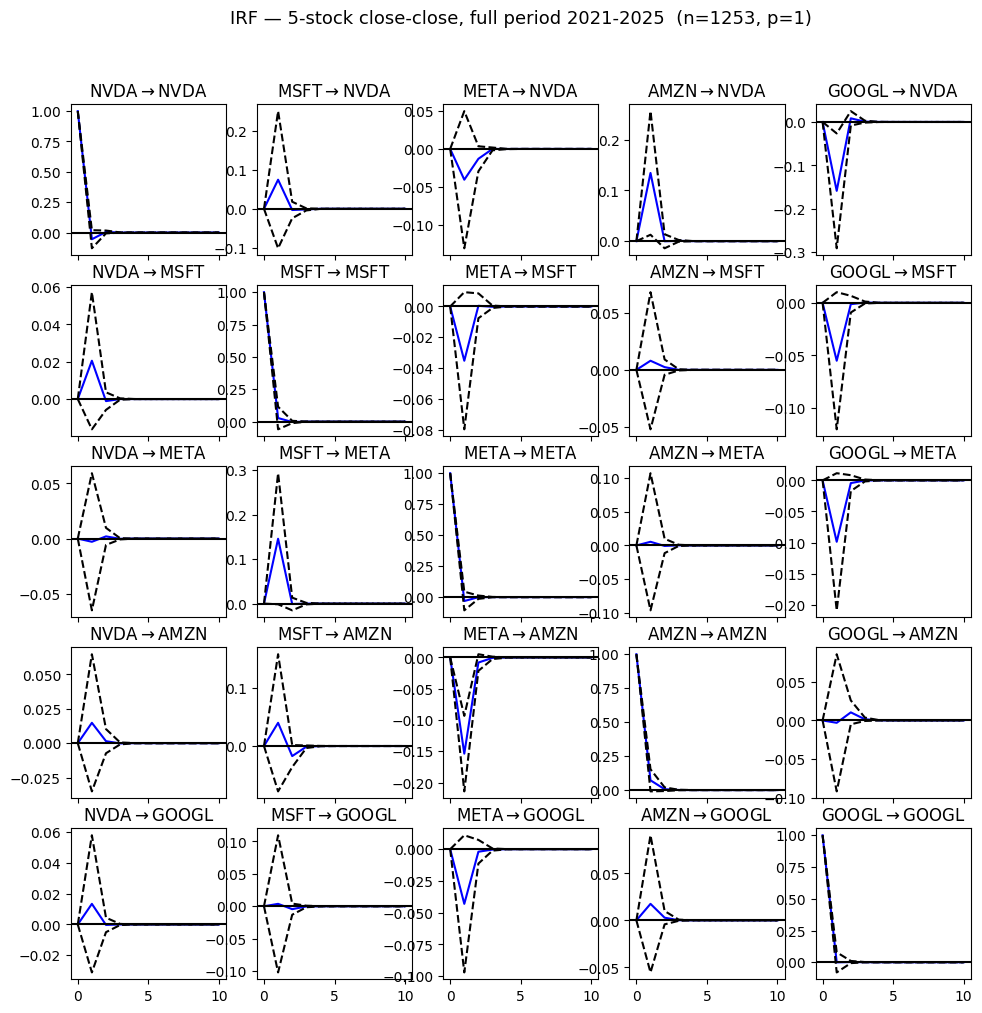

saved: output/irf_full_5stock.png  |  p=1


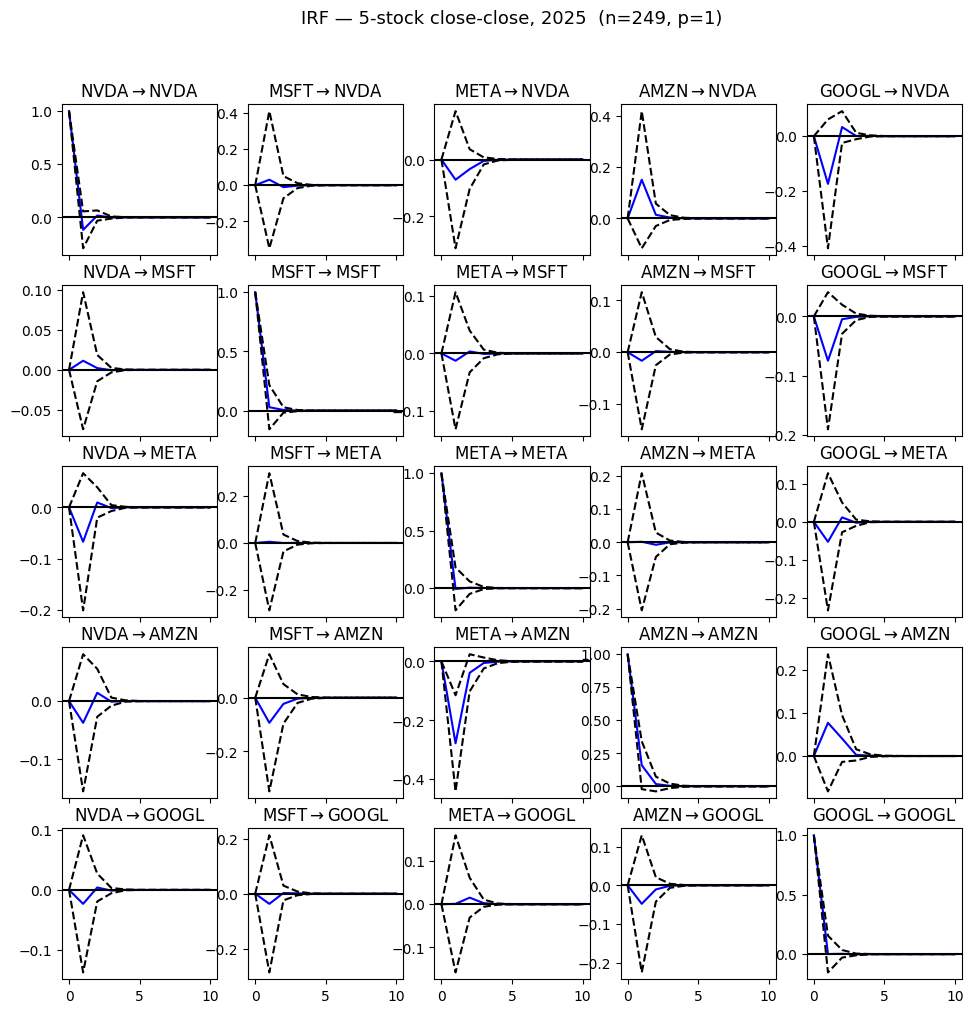

saved: output/irf_2025_5stock.png  |  p=1


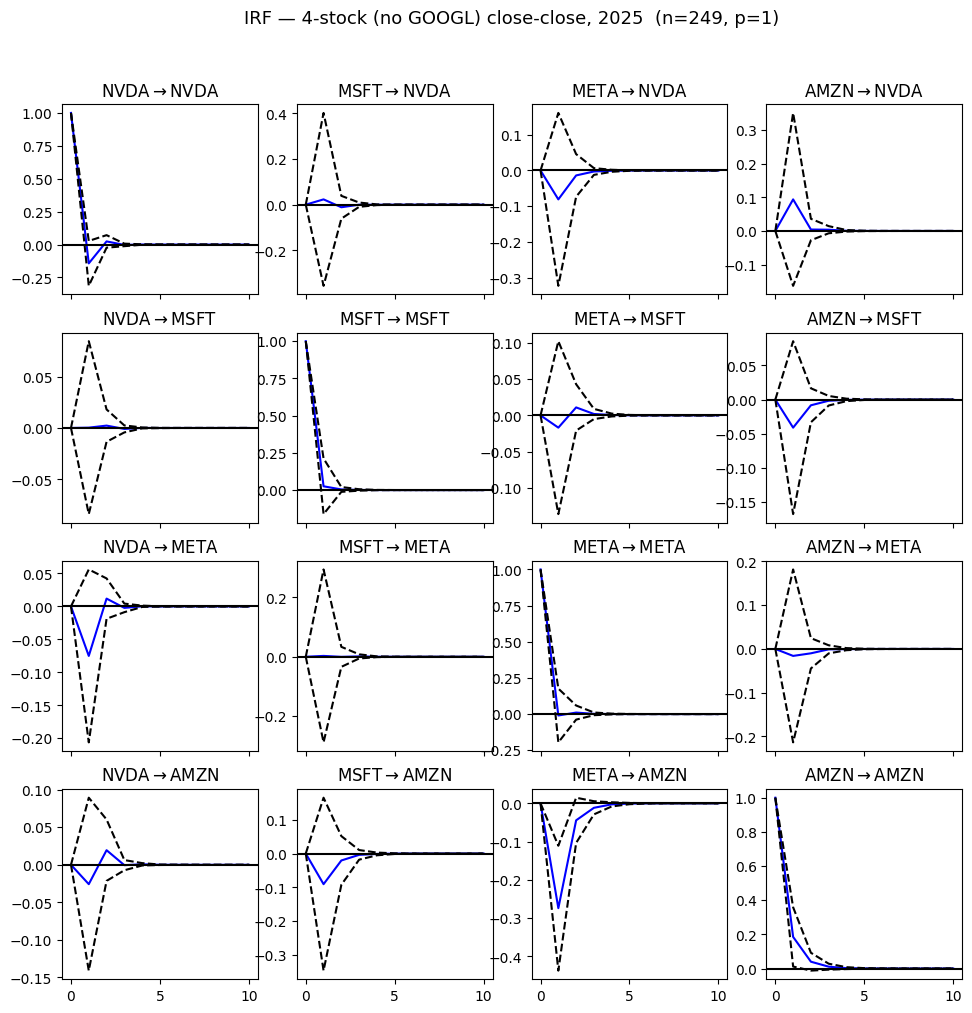

saved: output/irf_2025_4stock.png  |  p=1


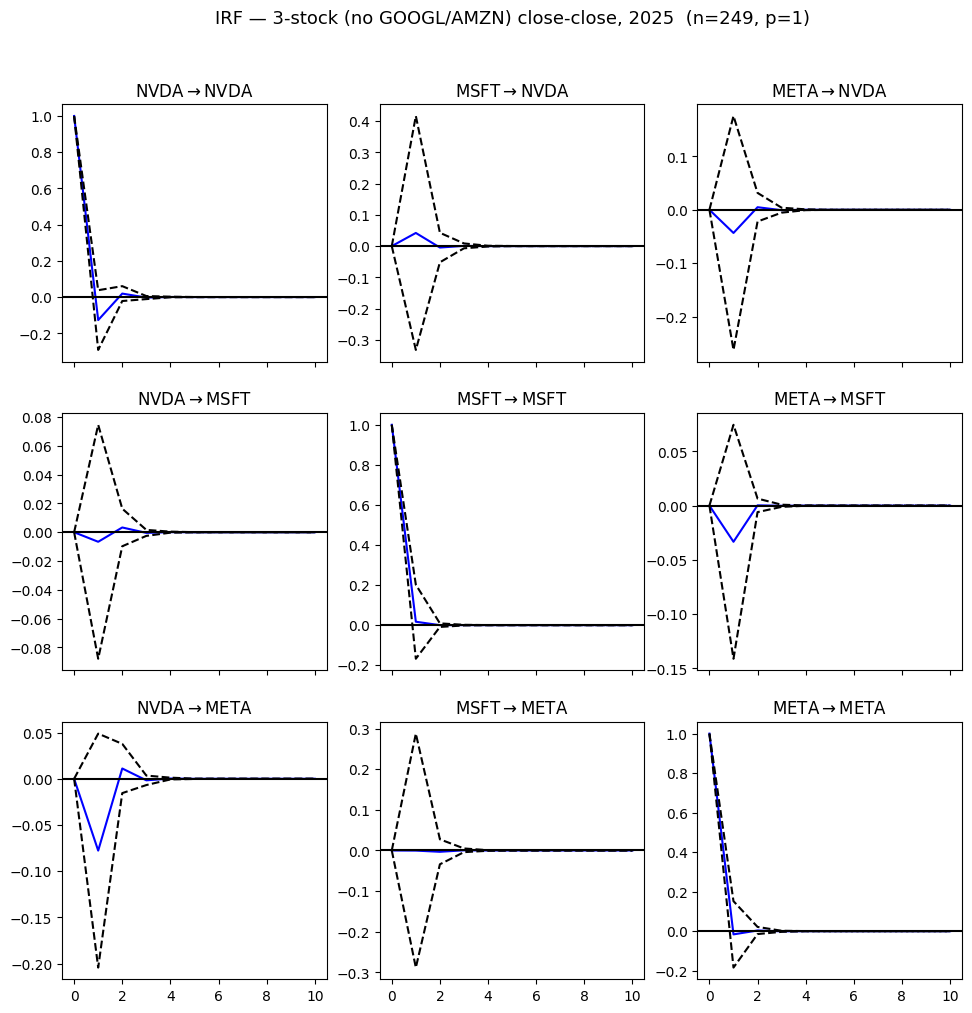

saved: output/irf_2025_3stock.png  |  p=1


(<statsmodels.tsa.vector_ar.var_model.VARResultsWrapper at 0x1939526fe10>, 1)

In [10]:
import matplotlib.pyplot as plt
import os
os.makedirs('output', exist_ok=True)

PERIODS = 10  # response horizon (days)


def plot_irf(mat, tickers, tag, title):
    fitted, p = fit_var(mat)
    irf = fitted.irf(periods=PERIODS)
    irf.plot(orth=False)
    plt.suptitle(f'{title}  (n={mat.shape[0]}, p={p})', y=1.02, fontsize=13)
    out = f'output/irf_{tag}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'saved: {out}  |  p={p}')
    return fitted, p


# --- 1. Full period 2021-2025, 5-stock ---
plot_irf(ret[TICKERS], TICKERS,
         'full_5stock',
         'IRF — 5-stock close-close, full period 2021-2025')

# --- 2. 2025, 5-stock ---
ret25_5 = ret[ret.index.year == 2025][TICKERS].dropna()
plot_irf(ret25_5, TICKERS,
         '2025_5stock',
         'IRF — 5-stock close-close, 2025')

# --- 3. 2025, 4-stock (no GOOGL) ---
plot_irf(ret25_4, GRP4,
         '2025_4stock',
         'IRF — 4-stock (no GOOGL) close-close, 2025')

# --- 4. 2025, 3-stock (no GOOGL/AMZN) ---
plot_irf(ret25_3, GRP3,
         '2025_3stock',
         'IRF — 3-stock (no GOOGL/AMZN) close-close, 2025')

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 323
TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']
PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']

df = pd.read_csv('data/table2_price_targets_final.csv')
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
df = df[df['Ticker'].isin(TICKERS)].sort_values(['Ticker', 'Date']).reset_index(drop=True)


def bsadf_series(y, r0):
    """Vectorized BSADF. ADF(const, no lag): dy = a + b*x + e, t-stat on b.
       For each endpoint, all start points computed at once via prefix-sum diffs."""
    T = len(y)
    min_win = int(np.floor(r0 * T))
    dy = np.diff(y)                 # len T-1
    x = y[:-1]                      # len T-1

    cs_x  = np.concatenate([[0.0], np.cumsum(x)])
    cs_xx = np.concatenate([[0.0], np.cumsum(x * x)])
    cs_y  = np.concatenate([[0.0], np.cumsum(dy)])
    cs_yy = np.concatenate([[0.0], np.cumsum(dy * dy)])
    cs_xy = np.concatenate([[0.0], np.cumsum(x * dy)])

    bsadf = np.full(T, np.nan)
    for r2 in range(min_win, T + 1):
        end = r2 - 1                          # dy/x window end (exclusive)
        starts = np.arange(0, end - min_win + 2)   # all valid r1 for this end
        if starts.size == 0:
            continue
        n   = end - starts                    # window lengths, vector
        Sx  = cs_x[end]  - cs_x[starts]
        Sxx = cs_xx[end] - cs_xx[starts]
        Sy  = cs_y[end]  - cs_y[starts]
        Syy = cs_yy[end] - cs_yy[starts]
        Sxy = cs_xy[end] - cs_xy[starts]

        det = n * Sxx - Sx * Sx
        b_hat = np.where(det > 0, (n * Sxy - Sx * Sy) / np.where(det > 0, det, 1), np.nan)
        a_hat = (Sy - b_hat * Sx) / n
        rss = Syy - a_hat * Sy - b_hat * Sxy
        with np.errstate(invalid='ignore', divide='ignore'):
            s2 = rss / (n - 2)
            var_b = s2 * n / det
            tstat = b_hat / np.sqrt(var_b)
        tstat = np.where((n >= 3) & (det > 0) & (rss > 0) & (var_b > 0), tstat, -np.inf)
        bsadf[r2 - 1] = np.nanmax(tstat) if np.any(np.isfinite(tstat)) else np.nan
    return bsadf


def gsadf_critical_series(T, r0, n_sim=499, seed=SEED, quantile=0.95):
    rng = np.random.default_rng(seed)
    sim = np.full((n_sim, T), np.nan)
    for s in range(n_sim):
        w = np.cumsum(rng.standard_normal(T))
        sim[s] = bsadf_series(w, r0)
    cv = np.nanquantile(sim, quantile, axis=0)
    return cv

In [12]:
def detect_bubbles(ticker, n_sim=499, min_episode=None):
    sub = df[df['Ticker'] == ticker].reset_index(drop=True)
    dates = sub['Date'].values
    y = np.log(sub['Close_t'].values)
    T = len(y)
    r0 = 0.01 + 1.8 / np.sqrt(T)

    bsadf = bsadf_series(y, r0)
    cv = gsadf_critical_series(T, r0, n_sim=n_sim)

    gsadf_stat = np.nanmax(bsadf)
    gsadf_cv = np.nanmax(cv)

    signal = np.zeros(T, dtype=bool)
    valid = ~np.isnan(bsadf) & ~np.isnan(cv)
    signal[valid] = bsadf[valid] > cv[valid]

    if min_episode is None:
        min_episode = int(np.floor(np.log(T)))

    episodes = []
    i = 0
    while i < T:
        if signal[i]:
            j = i
            while j < T and signal[j]:
                j += 1
            if (j - i) >= min_episode:
                episodes.append((dates[i], dates[j - 1], j - i))
            i = j
        else:
            i += 1

    verdict = 'REJECT null (bubble present)' if gsadf_stat > gsadf_cv else 'no bubble'
    print(f"{ticker}: GSADF={gsadf_stat:.3f}  CV(sup)={gsadf_cv:.3f}  {verdict}  "
          f"| min_episode={min_episode}d  n_episodes={len(episodes)}")
    for s, e, ln in episodes:
        print(f"   {pd.Timestamp(s).date()} -> {pd.Timestamp(e).date()}  ({ln}d)")

    return {'ticker': ticker, 'dates': dates, 'logprice': y,
            'bsadf': bsadf, 'cv': cv, 'signal': signal, 'episodes': episodes}


def plot_bubbles(res):
    dates, y, bsadf, cv = res['dates'], res['logprice'], res['bsadf'], res['cv']
    fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    fig.patch.set_facecolor('white')
    ax[0].plot(dates, y, color='#457B9D', lw=1.2)
    for s, e, _ in res['episodes']:
        ax[0].axvspan(s, e, color='#E63946', alpha=0.25)
    ax[0].set_ylabel('log(Close_t)')
    ax[0].set_title(f"{res['ticker']} — GSADF bubble detection (2021-2025)")
    ax[1].plot(dates, bsadf, color='#2A9D8F', lw=1.0, label='BSADF')
    ax[1].plot(dates, cv, color='#E63946', lw=1.0, ls='--', label='95% CV (pointwise)')
    ax[1].fill_between(dates, bsadf, cv, where=(bsadf > cv), color='#E63946', alpha=0.25)
    ax[1].set_ylabel('BSADF'); ax[1].legend(loc='upper left')
    plt.tight_layout(); plt.show()

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


NVDA: GSADF=2.198  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=9
   2021-11-04 -> 2021-12-02  (20d)
   2023-05-25 -> 2023-06-05  (7d)
   2023-06-08 -> 2023-06-27  (13d)
   2023-07-12 -> 2023-08-01  (15d)
   2024-02-01 -> 2024-02-20  (13d)
   2024-02-22 -> 2024-04-09  (33d)
   2024-05-14 -> 2024-07-29  (52d)
   2024-08-13 -> 2024-08-28  (12d)
   2024-11-06 -> 2024-11-22  (13d)


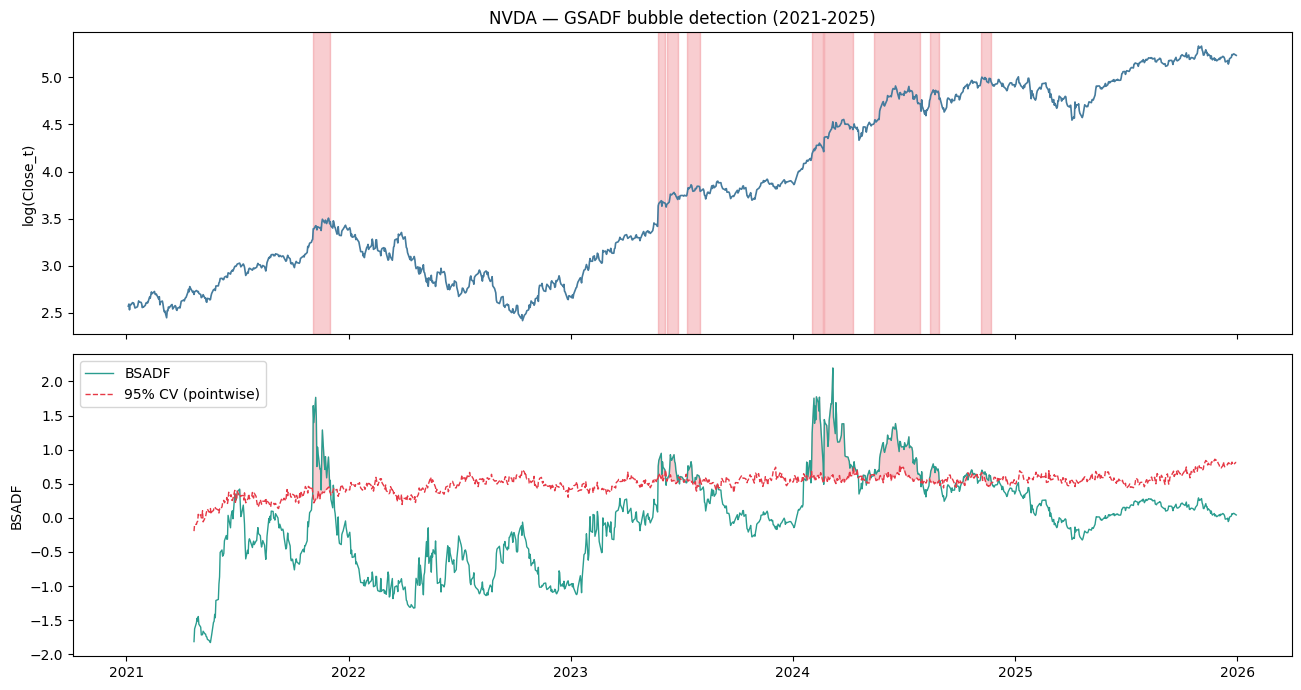

MSFT: GSADF=0.642  CV(sup)=0.861  no bubble  | min_episode=7d  n_episodes=0


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


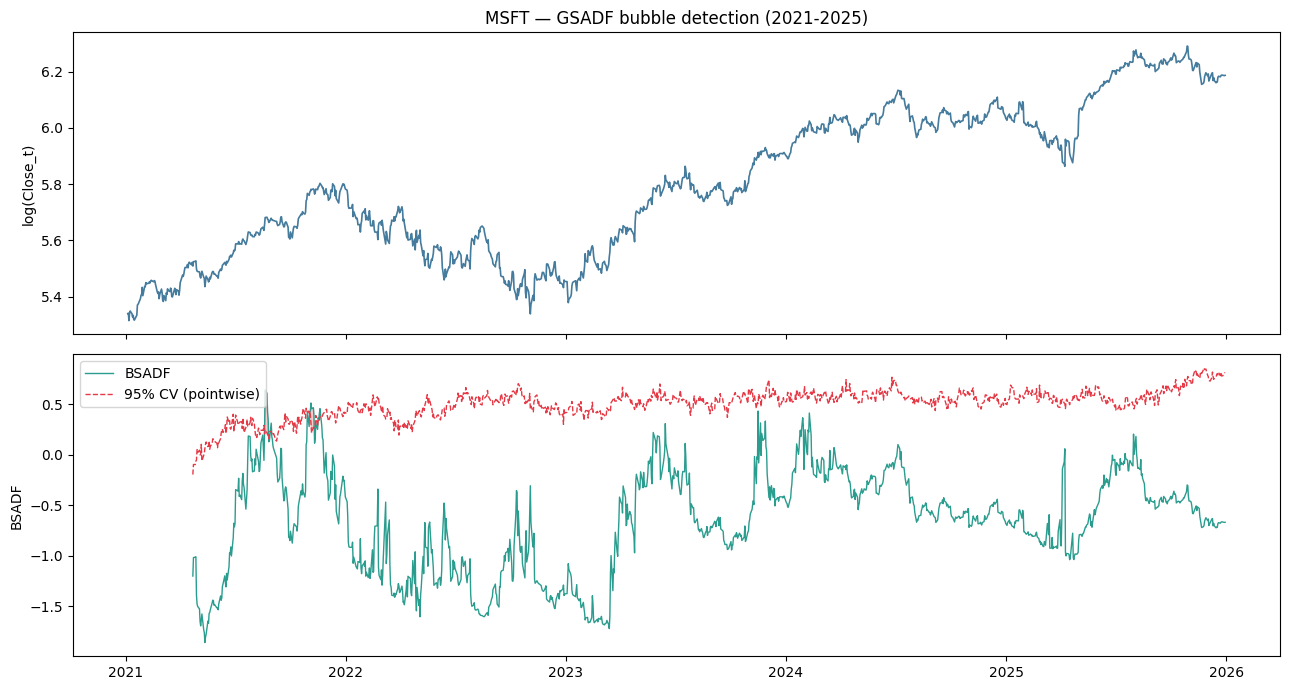

META: GSADF=1.678  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=4
   2022-03-03 -> 2022-03-15  (9d)
   2022-10-27 -> 2022-11-09  (10d)
   2024-02-02 -> 2024-02-12  (7d)
   2024-02-14 -> 2024-03-04  (13d)


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


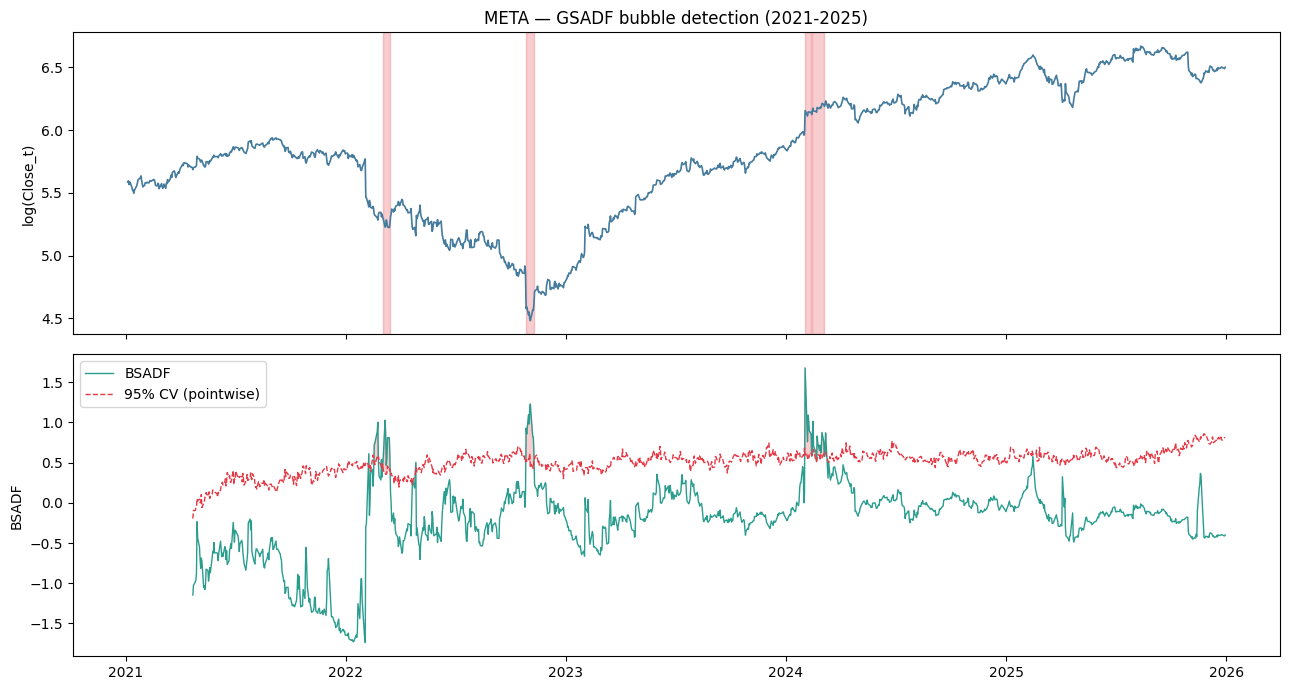

AMZN: GSADF=0.928  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=0


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


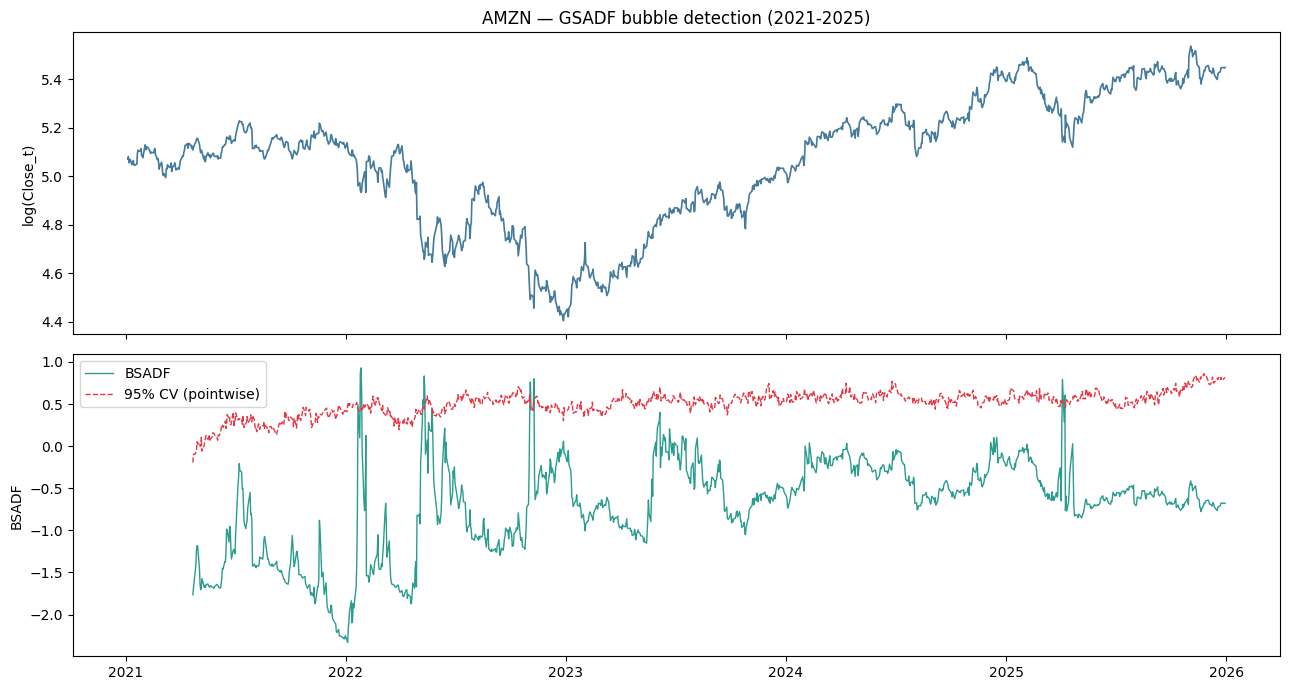

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


GOOGL: GSADF=1.499  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=3
   2021-08-24 -> 2021-09-01  (7d)
   2025-09-03 -> 2025-09-23  (15d)
   2025-11-21 -> 2025-12-11  (14d)


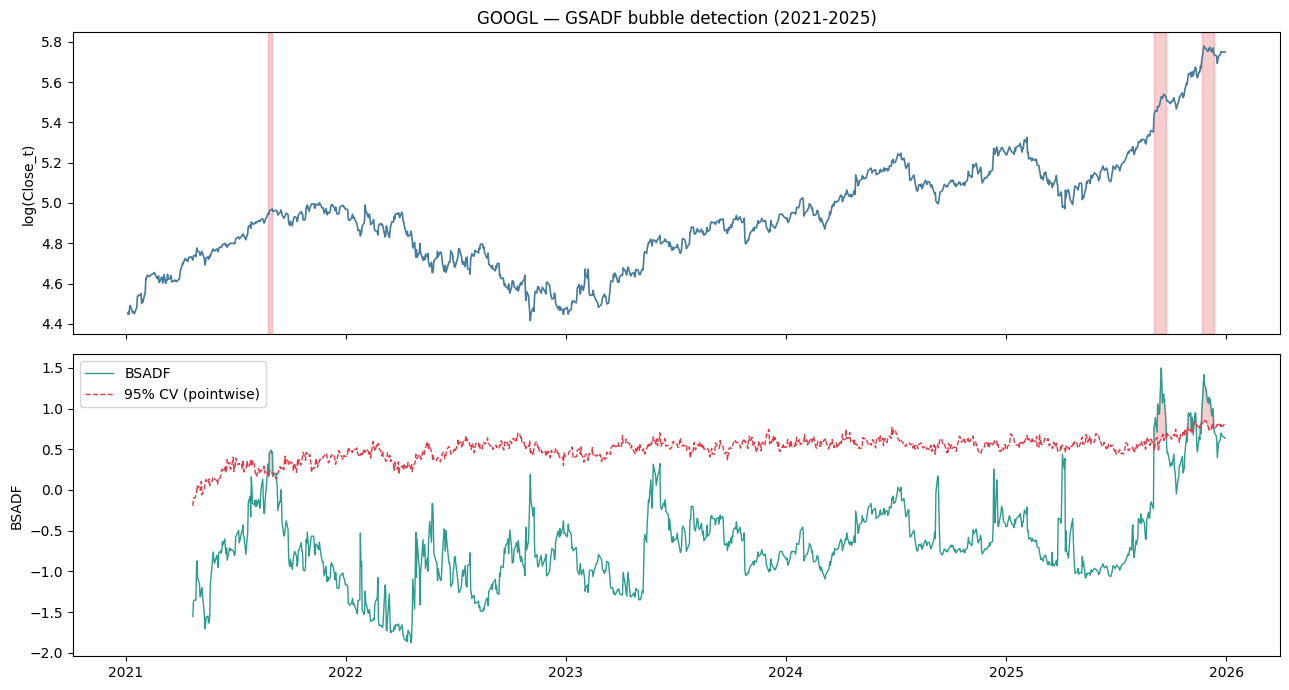

In [13]:
import os
os.makedirs('output', exist_ok=True)

results = {}
for tk in TICKERS:
    results[tk] = detect_bubbles(tk, n_sim=499)
    plot_bubbles(results[tk])

Ticker  GSADF  CV_sup Reject  N_episodes  Bubble_days Bubble_2025
  NVDA  2.198   0.861    Yes           9          178          No
  MSFT  0.642   0.861     No           0            0          No
  META  1.678   0.861    Yes           4           39          No
  AMZN  0.928   0.861    Yes           0            0          No
 GOOGL  1.499   0.861    Yes           3           36         Yes


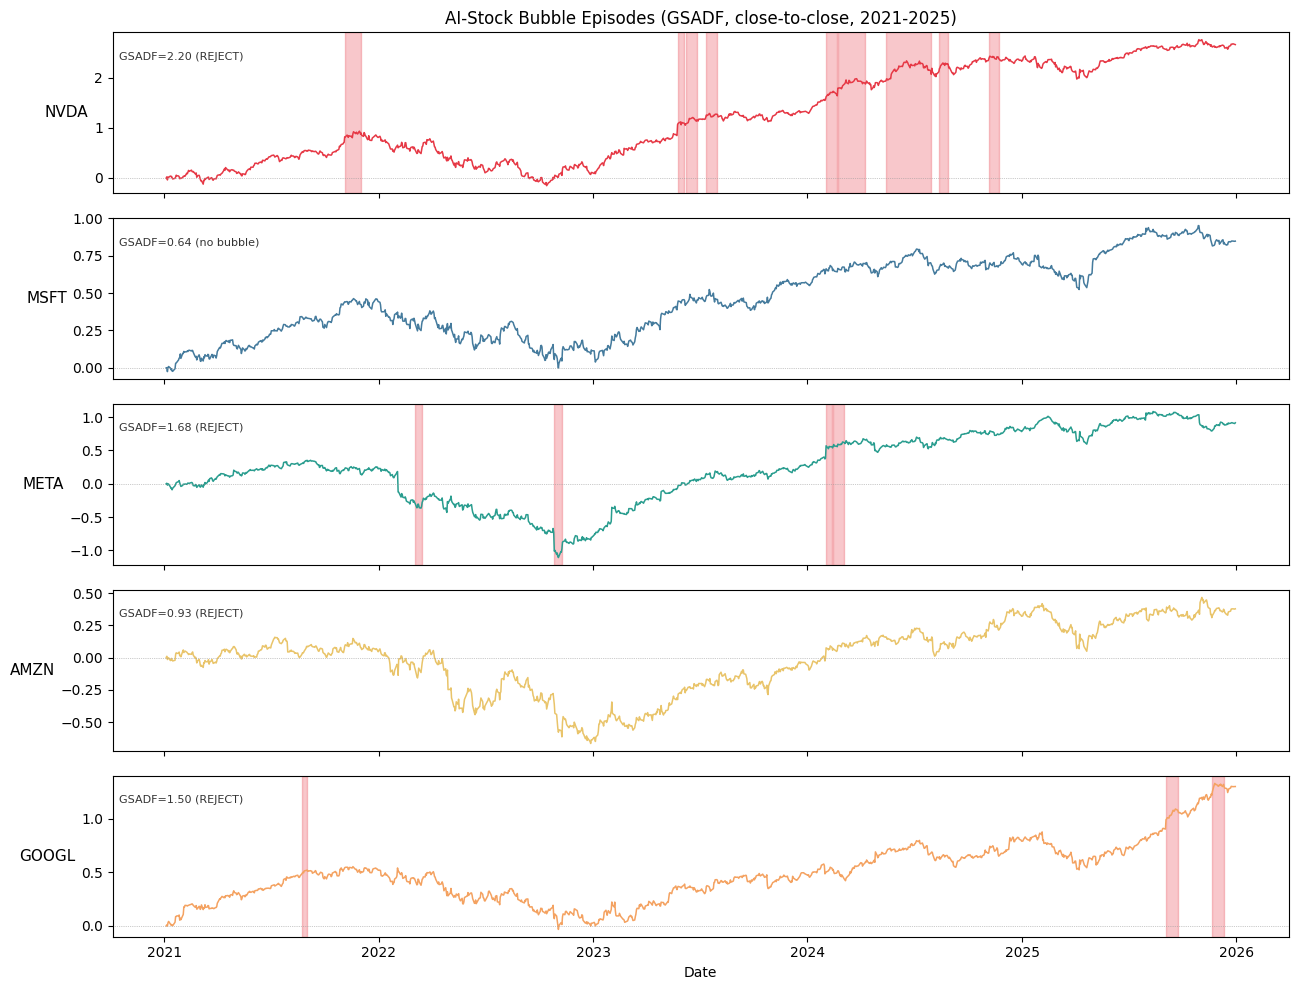

In [14]:
rows = []
for tk in TICKERS:
    r = results[tk]
    gs = np.nanmax(r['bsadf']); cv = np.nanmax(r['cv'])
    eps = r['episodes']
    bubble_days = sum(e[2] for e in eps)
    has_2025 = any(pd.Timestamp(e[0]).year == 2025 or pd.Timestamp(e[1]).year == 2025 for e in eps)
    rows.append({
        'Ticker': tk,
        'GSADF': round(gs, 3),
        'CV_sup': round(cv, 3),
        'Reject': 'Yes' if gs > cv else 'No',
        'N_episodes': len(eps),
        'Bubble_days': bubble_days,
        'Bubble_2025': 'Yes' if has_2025 else 'No',
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor('white')
for ax, tk, color in zip(axes, TICKERS, PALETTE):
    r = results[tk]
    dates, y = r['dates'], r['logprice']
    y0 = y - y[0]
    ax.plot(dates, y0, color=color, lw=1.1)
    for s, e, _ in r['episodes']:
        ax.axvspan(s, e, color='#E63946', alpha=0.28)
    gs = np.nanmax(r['bsadf']); cv = np.nanmax(r['cv'])
    tag = 'REJECT' if gs > cv else 'no bubble'
    ax.set_ylabel(tk, rotation=0, ha='right', va='center', fontsize=11)
    ax.text(0.005, 0.88, f"GSADF={gs:.2f} ({tag})", transform=ax.transAxes,
            fontsize=8, color='#333', va='top')
    ax.axhline(0, color='#999', lw=0.5, ls=':')
axes[0].set_title('AI-Stock Bubble Episodes (GSADF, close-to-close, 2021-2025)', fontsize=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('output/bubble_timeline_5stocks.png', dpi=150, bbox_inches='tight')
plt.show()

# Methods: VAR Spillover Test & GSADF Bubble Test

This module characterizes five AI stocks (NVDA / MSFT / META / AMZN / GOOGL) over 2021–2025 with two methods: cross-stock **lead–lag linkage**, and single-stock **bubble episode detection**.

---

## 1. VAR spillover test (off-the-shelf package)

**Implementation:** Uses `statsmodels`' `VAR` family directly (`select_order` for lag selection + `fit` + `test_causality`). No hand-written estimation — we only set the variables, feed in the data, and let the package estimate.

**Return definition:** Contemporaneous **close-to-close** return `r_t = Close_t / Close_{t-1} − 1` (same-period daily return) — **not** the t→t+1 next-day target `ret_total` used by NG-LP.

**Model:** All stocks enter a **single system of equations**; each stock's return today is regressed on the past few days of every stock's returns (including its own):

$$y_{i,t} = \alpha_i + \sum_{L=1}^{p}\sum_{j} \beta_{ij}^{(L)}\, y_{j,t-L} + \varepsilon_{i,t}$$

The lag order `p` is chosen automatically by AIC (`fit_var`).

**Two ways to read the output:**

- **Single-coefficient significance** (`sig_cross_stock`): pick cross-stock coefficients with `|t| > 1.96`, giving specific links like "A's return at lag L significantly predicts B."
- **Granger causality** (`test_causality`): an F-test that jointly tests whether **all lags** of A predict B, i.e. whether "A leads B."

**Stock combinations:** The test is rerun on different samples — full sample 2021–2025, year by year, and the 4-stock 2025 subsample excluding GOOGL — to see whether the linkage structure changes over time or with composition.

> Note: Granger "causality" is only statistical predictability; it may stem from a common market factor and does not imply true causation.

---

## 2. GSADF / BSADF bubble test (hand-written)

**Implementation:** Coded **from scratch in numpy** following Phillips-Shi-Yu (2015) — not a package. numpy only supplies array arithmetic and random numbers. The input is the **log price** `y = log(Close_t)`.

### Base: right-tailed ADF regression

Regress on a price subsample (simplest DF form, no lagged difference terms):

$$\Delta y_t = a + b\, y_{t-1} + \varepsilon_t$$

The regressor is **yesterday's price level** `y_{t-1}` (not time), and the test is **right-tailed**:

| $b = \rho - 1$ | Behavior |
|---|---|
| $b < 0$ | Mean-reverting (stationary) |
| $b = 0$ | Random walk (no bubble) |
| **$b > 0$** | **Explosive, self-reinforcing (bubble)** |

So testing `b>0 ⟺ ρ>1` (diverging first-order autocorrelation). The statistic is the t-value of b, $ADF = \hat b / \mathrm{se}(\hat b)$ — the larger, the more bubble-like.

### Three "sup" levels

With start $r_1$, end $r_2$, minimum window $r_0$, and $ADF_{r_1}^{r_2}$ the ADF value on $[r_1,r_2]$:

$$SADF(r_0)=\sup_{r_2} ADF_0^{r_2}\qquad(\text{fixed start})$$

$$BSADF_{r_2}(r_0)=\sup_{r_1\in[0,\,r_2-r_0]} ADF_{r_1}^{r_2}\qquad(\text{fixed end, sweep all starts})$$

$$GSADF(r_0)=\sup_{r_2} BSADF_{r_2}\qquad(\text{both start and end move})$$

`bsadf_series`: the endpoint rolls forward one day at a time; at each endpoint it looks back over all windows of length ≥ `min_win` and takes the max t-value — so it can automatically bracket a bubble whose start date is unknown. Window length lower bound `min_win = floor(r0·T)`, upper bound is "all data up to the current endpoint."

### Critical values and date-stamping

BSADF has no standard distribution, so critical values come from Monte Carlo (`gsadf_critical_series`): under the **null (random walk)**, simulate 499 series, compute BSADF for each, and take the pointwise 95% quantile as the critical curve $cv$.

- **Overall verdict:** $GSADF > \sup(cv)$ → reject the null, a bubble is present.
- **Date-stamping:** periods with $BSADF_{r_2} > cv_{r_2}^{0.95}$ are flagged as bubbles; a run counts only if it stays above the line for ≥ `min_episode` (≈ ln T) days, recording start/end dates (origination = upcrossing, collapse = downcrossing).

---

## Summary

Two takeaways frame the rest of the analysis:

**Weak cross-stock linkage.** VAR / Granger tests find little significant lead–lag structure among the stocks — especially among the core three in 2025, where almost no cross-stock coefficient is significant. The stocks move largely on their own information, not on each other. This is a **low signal-to-noise environment**, which is exactly why naive cross-stock prediction is hard and motivates the narrative-gated design later.

**Bubbles are stock-specific, not universal.** GSADF rejects the no-bubble null for several stocks, but the episodes are concentrated and idiosyncratic: **NVDA** is the dominant bubble stock, with its explosive run in **2024** (GSADF = 2.198, 178 bubble days), while **GOOGL** shows a bubble episode at the **end of 2025**. MSFT is cleanly non-bubble and AMZN is technically rejected with zero qualifying episodes. That the weak-AI GOOGL bubbles in a different period from the AI-core NVDA reinforces the control-experiment reading: bubble timing tracks each stock's own driver, not a single shared AI narrative.

---


# 3. From Failed Baselines to a Gated Design

This chapter is not a catalogue of failures — it is the reasoning that produces NG-LP.
Each method fails in a specific way, and each failure points to the design choice the
next method needs. The chain ends at a single realisation: in this small-sample, low-SNR
setting, the signal must be carried by the **gating structure**, not by a rawer scorer, a
more flexible learner, or a bigger model.

All methods share one setup, so only the model changes: the same features (FinBERT
`score` + five `bart_*` topics), the same **2021–2024 train / 2025 test** split, the same
**majority-class baseline**, and the same bootstrap confidence intervals and train–test
**overfit gap** as diagnostics.

We work through **five methods**, each answering the previous one's failure:

1. **Bagging decision tree & SVM** — flexible non-linear learners. They fit the training
   set but collapse to the baseline out-of-sample, with large train–test gaps: textbook
   overfitting when the sample is small and the signal weak.
2. **GLM logistic regression** — step back to a linear, interpretable model (direction on
   the five narrative categories). Less overfitting, but still no out-of-sample edge, and
   coefficients are mostly insignificant — the linear signal is genuinely faint, not just
   hidden by model variance.
3. **LSTM** — add sequence memory and more capacity, in case the signal is temporal. It
   overfits *worse* (a large train/test gap) and lands at the majority-class baseline —
   more capacity is the wrong direction here.
4. **Naive LP (ungated)** — the Local Projection machinery itself, fed FinBERT sentiment
   with **no narrative gating**. This is the decisive stepping stone: same estimator NG-LP
   will use, but without the gate it still fails — which localises the missing ingredient
   precisely to the **gate**, not the estimator.

Together with the **dictionary method** already rejected in Chapter 1, these establish one
conclusion: no off-the-shelf or higher-capacity model beats the baseline out-of-sample.
The problem is not the estimator — it is that the signal only appears once we condition on
*which narrative is active*. That is exactly what NG-LP adds in Chapter 4.



In [15]:
import numpy as np, pandas as pd
from sklearn.metrics import accuracy_score

RNG = 323
np.random.seed(RNG)

news = pd.read_csv('data/table1_news_scores_final.csv', parse_dates=['Date'])
price = pd.read_csv('data/table2_price_targets_final.csv', parse_dates=['Date'])

news['Date'] = news['Date'].dt.normalize()
price['Date'] = price['Date'].dt.normalize()

print(news.shape, price.shape)
print(sorted(news['Ticker'].unique()))

(13106, 15) (6270, 15)
['AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']


In [16]:
# Time split: 2021-2024 for training, 2025 for testing; applied to both tables
news_train  = news[news['Date'] <  '2025-01-01'].copy()
news_test   = news[news['Date'] >= '2025-01-01'].copy()
price_train = price[price['Date'] <  '2025-01-01'].copy()
price_test  = price[price['Date'] >= '2025-01-01'].copy()

print("news  train/test:", news_train.shape, news_test.shape)
print("price train/test:", price_train.shape, price_test.shape)

news  train/test: (8894, 15) (4212, 15)
price train/test: (5025, 15) (1245, 15)


In [17]:
BART = ['bart_chip', 'bart_power', 'bart_algorithm', 'bart_regulation', 'bart_earnings']

def build_daily(news_df, price_df, thr):
    n = news_df.copy()
    # Zero out each BART topic below threshold (< thr becomes 0)
    n[BART] = n[BART].where(n[BART] >= thr, 0.0)
    # Drop rows with low finbert_conf
    n = n[n['finbert_conf'] >= thr].copy()
    n['fin_sign'] = np.sign(n['finbert_score'])

     # BART topics: sum of non-zero values / count of non-zero values (non-zero mean)
    def agg_group(g):
        out = {}
        for c in BART:
            nz = g[c][g[c] > 0]
            out[c] = nz.mean() if len(nz) > 0 else 0.0
        out['fin_sign'] = g['fin_sign'].mean()
        out['finbert_conf'] = g['finbert_conf'].mean()
        return pd.Series(out)
    
    daily = n.groupby(['Date', 'Ticker']).apply(agg_group).reset_index()
    out = daily.merge(price_df[['Date', 'Ticker', 'dir_total']],
                      on=['Date', 'Ticker'], how='inner')
    return out

FEATURES = BART + ['fin_sign', 'finbert_conf']

for thr in [0.5, 0.6, 0.7]:
    tr = build_daily(news_train, price_train, thr)
    te = build_daily(news_test, price_test, thr)
    print(f"thr={thr} | train {tr.shape[0]} | test {te.shape[0]} | pos {tr['dir_total'].mean():.3f}")


thr=0.5 | train 1634 | test 659 | pos 0.512
thr=0.6 | train 1473 | test 611 | pos 0.514
thr=0.7 | train 1268 | test 562 | pos 0.506


In [18]:
for thr in [0.5, 0.6, 0.7]:
    tr = build_daily(news_train, price_train, thr)
    te = build_daily(news_test, price_test, thr)
    print(f"--- thr={thr} ---")
    for tk in ['NVDA','MSFT','META','AMZN','GOOGL']:
        ntr = (tr['Ticker']==tk).sum()
        nte = (te['Ticker']==tk).sum()
        pos = tr[tr['Ticker']==tk]['dir_total'].mean()
        print(f"  {tk:6} train {ntr:4d} | test {nte:4d} | pos {pos:.3f}")

--- thr=0.5 ---
  NVDA   train  211 | test  132 | pos 0.569
  MSFT   train  309 | test  127 | pos 0.511
  META   train  289 | test  141 | pos 0.502
  AMZN   train  567 | test  142 | pos 0.490
  GOOGL  train  258 | test  117 | pos 0.523
--- thr=0.6 ---
  NVDA   train  198 | test  128 | pos 0.566
  MSFT   train  276 | test  119 | pos 0.511
  META   train  258 | test  128 | pos 0.512
  AMZN   train  513 | test  131 | pos 0.491
  GOOGL  train  228 | test  105 | pos 0.526
--- thr=0.7 ---
  NVDA   train  173 | test  121 | pos 0.572
  MSFT   train  236 | test  110 | pos 0.521
  META   train  220 | test  121 | pos 0.500
  AMZN   train  449 | test  118 | pos 0.474
  GOOGL  train  190 | test   92 | pos 0.505


In [19]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']

def boot_ci(y, p, n=5000):
    y, p = np.asarray(y), np.asarray(p)
    accs = [accuracy_score(y[i], p[i])
            for i in (np.random.choice(len(y), len(y), True) for _ in range(n))]
    return np.percentile(accs, 2.5), np.percentile(accs, 97.5)

def make_models():
    tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=RNG)
    return {
        'Bagging': BaggingClassifier(tree, n_estimators=200, random_state=RNG),
        'SVM': make_pipeline(StandardScaler(),
                             SVC(kernel='rbf', C=1.0, class_weight='balanced',
                                 random_state=RNG)),
    }

for thr in [0.5, 0.6, 0.7]:
    tr = build_daily(news_train, price_train, thr)
    te = build_daily(news_test,  price_test,  thr)
    print(f"\n========== thr={thr} ==========")
    for tk in TICKERS:
        a = tr[tr['Ticker']==tk]; b = te[te['Ticker']==tk]
        Xtr, ytr = a[FEATURES].values, a['dir_total'].values
        Xte, yte = b[FEATURES].values, b['dir_total'].values
        base = max(yte.mean(), 1-yte.mean())
        for name, m in make_models().items():
            m.fit(Xtr, ytr)
            tr_acc = accuracy_score(ytr, m.predict(Xtr))
            pred   = m.predict(Xte)
            te_acc = accuracy_score(yte, pred)
            lo, hi = boot_ci(yte, pred)
            sig = "*" if lo > base else " "
            print(f"  {tk:6} {name:8} train {tr_acc:.3f} | test {te_acc:.3f} "
                  f"| base {base:.3f} | gap {tr_acc-te_acc:+.3f} "
                  f"| CI[{lo:.3f},{hi:.3f}] {sig}")


========== thr=0.5 ==========
  NVDA   Bagging  train 0.664 | test 0.523 | base 0.530 | gap +0.141 | CI[0.439,0.606]  
  NVDA   SVM      train 0.673 | test 0.500 | base 0.530 | gap +0.173 | CI[0.417,0.583]  
  MSFT   Bagging  train 0.650 | test 0.488 | base 0.551 | gap +0.162 | CI[0.402,0.575]  
  MSFT   SVM      train 0.644 | test 0.598 | base 0.551 | gap +0.046 | CI[0.512,0.677]  
  META   Bagging  train 0.619 | test 0.468 | base 0.518 | gap +0.151 | CI[0.390,0.553]  
  META   SVM      train 0.606 | test 0.546 | base 0.518 | gap +0.059 | CI[0.461,0.624]  
  AMZN   Bagging  train 0.607 | test 0.486 | base 0.507 | gap +0.121 | CI[0.401,0.564]  
  AMZN   SVM      train 0.580 | test 0.528 | base 0.507 | gap +0.052 | CI[0.444,0.613]  
  GOOGL  Bagging  train 0.624 | test 0.487 | base 0.530 | gap +0.137 | CI[0.402,0.573]  
  GOOGL  SVM      train 0.663 | test 0.496 | base 0.530 | gap +0.167 | CI[0.410,0.590]  

========== thr=0.6 ==========
  NVDA   Bagging  train 0.667 | test 0.523 | bas

In [20]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']

def build_newslevel(news_df, price_df, thr):
    n = news_df.copy()
    n[BART] = n[BART].where(n[BART] >= thr, 0.0)
    n = n[n['finbert_conf'] >= thr].copy()
    n['fin_sign'] = np.sign(n['finbert_score'])
    out = n.merge(price_df[['Date', 'Ticker', 'dir_total']],
                  on=['Date', 'Ticker'], how='inner')
    return out[['Date', 'Ticker'] + FEATURES + ['dir_total']]

def make_model(name):
    if name == 'Bagging':
        base = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=RNG)
        return BaggingClassifier(base, n_estimators=200, random_state=RNG)
    svc = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=RNG)
    return make_pipeline(StandardScaler(), CalibratedClassifierCV(svc, ensemble=False))

def day_signal(df, proba):
    d = df[['Date', 'dir_total']].copy()
    d['s'] = proba - 0.5
    g = d.groupby('Date').agg(net=('s', 'sum'), y=('dir_total', 'first')).reset_index()
    g['pred'] = (g['net'] > 0).astype(int)
    return g

def boot_ci_days(g, n_boot=5000):
    y, pr = g['y'].values, g['pred'].values
    acc = [accuracy_score(y[i], pr[i])
           for i in (np.random.choice(len(y), len(y), True) for _ in range(n_boot))]
    return np.percentile(acc, 2.5), np.percentile(acc, 97.5)

rows = []
for thr in [0.5, 0.6, 0.7]:
    tr_all = build_newslevel(news_train, price_train, thr)
    te_all = build_newslevel(news_test,  price_test,  thr)
    for tk in TICKERS:
        a = tr_all[tr_all['Ticker'] == tk]
        b = te_all[te_all['Ticker'] == tk]
        for name in ['Bagging', 'SVM']:
            m = make_model(name).fit(a[FEATURES].values, a['dir_total'].values)
            gtr = day_signal(a, m.predict_proba(a[FEATURES].values)[:, 1])
            gte = day_signal(b, m.predict_proba(b[FEATURES].values)[:, 1])
            base = max(gte['y'].mean(), 1 - gte['y'].mean())
            tr_acc = accuracy_score(gtr['y'], gtr['pred'])
            te_acc = accuracy_score(gte['y'], gte['pred'])
            lo, hi = boot_ci_days(gte)
            rows.append({'thr': thr, 'ticker': tk, 'model': name,
                         'train_acc': round(tr_acc, 3), 'test_acc': round(te_acc, 3),
                         'baseline': round(base, 3), 'gap': round(tr_acc - te_acc, 3),
                         'ci_low': round(lo, 3), 'ci_high': round(hi, 3),
                         'significant': lo > base})

results = pd.DataFrame(rows)

print(f"\nSignificant (CI low > baseline): {results['significant'].sum()} / {len(results)}")
print(f"Mean overfit gap (Bagging): {results[results.model=='Bagging']['gap'].mean():+.3f}")
print(f"Mean overfit gap (SVM):     {results[results.model=='SVM']['gap'].mean():+.3f}")
results  


Significant (CI low > baseline): 0 / 30
Mean overfit gap (Bagging): +0.127
Mean overfit gap (SVM):     +0.002


,thr,ticker,model,train_acc,test_acc,baseline,gap,ci_low,ci_high,significant
0,0.5,NVDA,Bagging,0.640,0.553,0.530,0.087,0.470,0.636,False
1,0.5,NVDA,SVM,0.483,0.523,0.530,-0.039,0.439,0.606,False
2,0.5,MSFT,Bagging,0.592,0.535,0.551,0.057,0.449,0.622,False
3,0.5,MSFT,SVM,0.511,0.551,0.551,-0.040,0.465,0.638,False
4,0.5,META,Bagging,0.633,0.426,0.518,0.208,0.348,0.511,False
5,0.5,META,SVM,0.588,0.539,0.518,0.049,0.461,0.624,False
6,0.5,AMZN,Bagging,0.612,0.444,0.507,0.168,0.359,0.521,False
7,0.5,AMZN,SVM,0.510,0.493,0.507,0.017,0.408,0.570,False
8,0.5,GOOGL,Bagging,0.620,0.479,0.530,0.142,0.385,0.573,False
9,0.5,GOOGL,SVM,0.523,0.530,0.530,-0.007,0.436,0.615,False


## 3.1 Bagging Decision Tree & SVM

**Setup.** Per ticker, a 7-dim feature vector — five gated `bart_*` topics (non-zero
mean after the threshold) plus `fin_sign` (mean FinBERT sign) and `finbert_conf` (mean
confidence) — predicts next-day direction `dir_total`. Two aggregation views: **day-level**
(one row per trading day) and **news-level** (one row per article, then aggregated to a
daily net-vote signal). Two flexible non-linear learners: **Bagging** (200 depth-3 trees)
and an **RBF-kernel SVM** (standardised, class-balanced). Trained 2021–2024, tested 2025,
across thresholds 0.5 / 0.6 / 0.7, and judged against the majority-class baseline with a
5,000-sample bootstrap 95% CI (significant ⟺ CI lower bound > baseline).

**Result — nothing survives.** At the news level, **0 of 30** (5 tickers × 3 thresholds ×
2 models) combinations are significant. Bagging overfits systematically — train accuracy
of 0.60–0.67 collapses to 0.45–0.55 out-of-sample, a mean **train–test gap of +0.127**
(e.g. NVDA day-level: train 0.664 / test 0.523, gap +0.141). SVM's news-level gap looks
small (+0.002) only because the calibrated model predicts almost constantly, not because
it finds signal; the occasional high test value (e.g. MSFT SVM 0.597) has a CI that still
covers the baseline — noise, not edge.

**Reading.** Flexible learners can memorise the training set but generalise no better than
guessing the majority class. This is textbook overfitting in a small-sample, low-SNR
regime, and it motivates stepping *back* to a simpler, interpretable model next.



In [21]:
import numpy as np, pandas as pd
import statsmodels.api as sm

# ---- config ----
TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']
CATS    = ['chip', 'power', 'algorithm', 'regulation', 'earnings']
CONF_TH = 0.6          # FinBERT confidence gate
BART_TH = 0.6          # BART topic gate (soft, multi-membership)
SEED    = 323
np.random.seed(SEED)

# ---- load ----
news  = pd.read_csv('data/table1_news_scores_final.csv', encoding='utf-8-sig')
price = pd.read_csv('data/table2_price_targets_final.csv', encoding='utf-8-sig')
news['Date']  = pd.to_datetime(news['Date']).dt.normalize()
price['Date'] = pd.to_datetime(price['Date']).dt.normalize()

# ---- time split: 2021-2024 train / 2025 test ----
news_train  = news[news['Date']  <  '2025-01-01'].copy()
news_test   = news[news['Date']  >= '2025-01-01'].copy()
price_train = price[price['Date'] <  '2025-01-01'].copy()
price_test  = price[price['Date'] >= '2025-01-01'].copy()

# ---- build news-level features (double-0.6 gate, BART multi-membership) ----
def build_glm_data(news_df, price_df):
    n = news_df.copy()
    n = n[n['finbert_conf'] >= CONF_TH].copy()          # confidence gate (row-level)
    # each category column = finbert_score if that topic passes BART gate, else 0;
    # one news can populate several category columns (multi-membership)
    for cat in CATS:
        gate = n[f'bart_{cat}'] >= BART_TH
        n[cat] = np.where(gate, n['finbert_score'], 0.0)
    # drop news that hit no category at all
    n = n[(n[CATS] != 0).any(axis=1)].copy()
    out = n.merge(price_df[['Date', 'Ticker', 'dir_total']],
                  on=['Date', 'Ticker'], how='inner')
    return out

In [22]:
# ---- in-sample GLM logit per ticker: beta + significance ----
tr = build_glm_data(news_train, price_train)

for tk in TICKERS:
    a = tr[tr['Ticker'] == tk]
    X = sm.add_constant(a[CATS])
    y = a['dir_total']
    model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
    print(f"\n===== {tk} (n={len(a)}) =====")
    for name in ['const'] + CATS:
        b = model.params[name]; p = model.pvalues[name]
        star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"  {name:12} beta={b:+.4f}  p={p:.3f} {star}")


===== NVDA (n=362) =====
  const        beta=+0.0325  p=0.780 
  chip         beta=-0.0906  p=0.674 
  power        beta=+0.0179  p=0.954 
  algorithm    beta=+0.4493  p=0.084 *
  regulation   beta=+0.0626  p=0.888 
  earnings     beta=-0.3674  p=0.123 

===== MSFT (n=220) =====
  const        beta=-0.0399  p=0.790 
  chip         beta=+0.0875  p=0.876 
  power        beta=+0.4988  p=0.147 
  algorithm    beta=-0.3700  p=0.256 
  regulation   beta=-0.7194  p=0.091 *
  earnings     beta=+0.2631  p=0.321 

===== META (n=157) =====
  const        beta=+0.0573  p=0.771 
  chip         beta=+0.0631  p=0.946 
  power        beta=+0.2148  p=0.662 
  algorithm    beta=-0.8993  p=0.059 *
  regulation   beta=+0.3495  p=0.466 
  earnings     beta=+0.5957  p=0.045 **

===== AMZN (n=259) =====
  const        beta=-0.0157  p=0.916 
  chip         beta=-0.0871  p=0.861 
  power        beta=-0.0624  p=0.814 
  algorithm    beta=-0.1154  p=0.743 
  regulation   beta=+0.1378  p=0.728 
  earnings     be

In [23]:
from sklearn.metrics import accuracy_score

te = build_glm_data(news_test, price_test)

def day_signal_glm(df, proba):
    d = df[['Date', 'dir_total']].copy()
    d['s'] = proba - 0.5                                  # signal centered at 0.5
    g = d.groupby('Date').agg(net=('s', 'sum'),
                              y=('dir_total', 'first')).reset_index()
    g['pred'] = (g['net'] > 0).astype(int)               # net positive -> predict up
    return g

def boot_ci_days(g, n_boot=5000):
    y, pr = g['y'].values, g['pred'].values
    acc = [accuracy_score(y[i], pr[i])
           for i in (np.random.choice(len(y), len(y), True) for _ in range(n_boot))]
    return np.percentile(acc, 2.5), np.percentile(acc, 97.5)

print("===== GLM out-of-sample (2025) =====")
for tk in TICKERS:
    a = tr[tr['Ticker'] == tk]; b = te[te['Ticker'] == tk]
    m = sm.GLM(a['dir_total'], sm.add_constant(a[CATS]),
               family=sm.families.Binomial()).fit()
    X_te = sm.add_constant(b[CATS], has_constant='add')  # force intercept, align columns
    p_te = m.predict(X_te)
    g = day_signal_glm(b, p_te.values)
    base = max(g['y'].mean(), 1 - g['y'].mean())
    acc  = accuracy_score(g['y'], g['pred'])
    lo, hi = boot_ci_days(g)
    sig = '*' if lo > base else ' '
    print(f"  {tk:6} days={len(g):3d} | test {acc:.3f} | base {base:.3f} "
          f"| CI[{lo:.3f},{hi:.3f}] {sig}")

===== GLM out-of-sample (2025) =====
  NVDA   days=111 | test 0.505 | base 0.541 | CI[0.414,0.595]  
  MSFT   days= 74 | test 0.608 | base 0.541 | CI[0.500,0.716]  
  META   days= 79 | test 0.506 | base 0.519 | CI[0.392,0.620]  
  AMZN   days= 64 | test 0.547 | base 0.516 | CI[0.422,0.672]  
  GOOGL  days= 74 | test 0.500 | base 0.568 | CI[0.392,0.608]  


## 3.2 GLM Logistic Regression

**Flow.**
1. **Double 0.6 gate (news-level).** Keep articles with `finbert_conf ≥ 0.6`. For each of
   the five categories, set that column to the signed `finbert_score` if `bart_cat ≥ 0.6`,
   else 0 — so one article can load several categories (multi-membership). Drop articles
   that hit no category.
2. **In-sample logit, per ticker.** Regress next-day direction on the five category signals
   plus an intercept, and read each coefficient's sign and significance.
3. **Out-of-sample (2025).** Predict a per-article up-probability, aggregate to a daily
   **net-vote** signal (`Σ(p − 0.5) > 0 ⇒ up`), and score accuracy against the
   majority-class baseline with a 5,000-sample bootstrap CI.

**Model.** A per-ticker logistic (GLM, Binomial) with

$$\Pr(\text{dir}_t = 1 \mid x_t) = \sigma\!\Big(\beta_0 + \sum_{c \in \mathcal{C}} \beta_c\, x_{c,t}\Big),
\qquad \sigma(z) = \frac{1}{1 + e^{-z}},$$

where $\mathcal{C} = \{$chip, power, algorithm, regulation, earnings$\}$ and
$x_{c,t} = \text{finbert\_score}$ if that article passes the BART gate for category $c$,
else $0$.

**Results — in-sample coefficients are mostly noise.** Across the five stocks, almost every
$\beta_c$ is insignificant, and the few that reach $p < 0.1$ do not agree across stocks or
even in sign: NVDA `algorithm` $+0.449\,(p{=}.084)$ but META `algorithm` $-0.899\,(p{=}.059)$;
META `earnings` $+0.596\,(p{=}.045)$; GOOGL `power` $+0.970\,(p{=}.046)$; MSFT `regulation`
$-0.719\,(p{=}.091)$. No stable narrative-to-return mapping emerges.

**Results — no out-of-sample edge.** In 2025 no ticker is significant (CI lower bound never
clears the baseline):

| Ticker | Test | Baseline | 95% CI |
|---|---|---|---|
| NVDA | 0.505 | 0.541 | [0.414, 0.595] |
| MSFT | 0.608 | 0.541 | [0.500, 0.716] |
| META | 0.506 | 0.519 | [0.392, 0.620] |
| AMZN | 0.547 | 0.516 | [0.422, 0.672] |
| GOOGL | 0.500 | 0.568 | [0.392, 0.608] |

MSFT looks best (0.608) but its CI floor (0.500) still sits below the baseline (0.541).

**Reading.** Stepping back to a linear, interpretable model removes the overfitting of §3.1
but confirms the harder problem: the linear narrative signal is genuinely faint, and a single
global mapping from category sentiment to direction does not generalise. What is still missing
is *conditioning on which narrative is active for which stock* — the idea the remaining methods
pursue.



In [ ]:
import pandas as pd, numpy as np
from numpy.linalg import lstsq
import statsmodels.api as sm   

TICKERS = ['NVDA','MSFT','META','AMZN','GOOGL']
CATS = ['chip','power','algorithm','regulation','earnings']
CONF_TH = 0.6; BART_TH = 0.6; SENT_MIN = 0.05; SEED = 323; NBOOT = 5000
TRAIN_START = '2021-01-01'; TRAIN_END = '2025-01-01'; TEST_START = '2025-01-01'; BASE_YEAR = 2024

t2 = pd.read_csv('data/table2_price_targets_final.csv'); t2['Date'] = pd.to_datetime(t2['Date']).dt.normalize()
news = pd.read_csv('data/table1_news_scores_final.csv', encoding='utf-8-sig'); news['Date'] = pd.to_datetime(news['Date']).dt.normalize()

def build(ticker):
    s = t2[t2.Ticker == ticker].sort_values('Date').reset_index(drop=True).copy()
    s['Daily_Return'] = s['Close_t'].pct_change(); s['next_return'] = s['ret_total']
    d = s[['Date','Daily_Return','next_return']].dropna().reset_index(drop=True)
    nk = news[news.Ticker == ticker]
    for cat in CATS:
        sub = nk[(nk.finbert_conf >= CONF_TH) & (nk[f'bart_{cat}'] >= BART_TH)]
        a = sub.groupby('Date')['finbert_score'].mean().reset_index(); a.columns = ['Date', f'{cat}_sent']
        d = d.merge(a, on='Date', how='left'); d[f'{cat}_sent'] = d[f'{cat}_sent'].fillna(0)
    return d

def base_2024(ticker):
    d = build(ticker)
    d24 = d[(d['Date'] >= f'{BASE_YEAR}-01-01') & (d['Date'] < f'{BASE_YEAR+1}-01-01')]
    return (d24['next_return'] > 0).mean()

def collect_votes_ablation(ticker):
    """FinBERT+LP, NO gating. Fixed beta from 2021-2024, predict 2025 signal days."""
    d = build(ticker)
    votes = {}
    for cat in CATS:
        col = f'{cat}_sent'
        dd = d[d[col].abs() > SENT_MIN][['Date', col, 'Daily_Return', 'next_return']].dropna().reset_index(drop=True)
        if dd.empty: continue
        tr = dd[(dd['Date'] >= TRAIN_START) & (dd['Date'] < TRAIN_END)]
        if len(tr) < 15: continue
        Xtr = np.column_stack([tr[col].values, tr['Daily_Return'].values, np.ones(len(tr))])
        beta = lstsq(Xtr, tr['next_return'].values, rcond=None)[0][0]
        te = dd[dd['Date'] >= TEST_START]
        for _, r in te.iterrows():
            di_ts = pd.Timestamp(r['Date'])
            pred_up = (beta * r[col]) > 0; act_up = r['next_return'] > 0
            if di_ts not in votes: votes[di_ts] = [0, 0, act_up, di_ts.year]
            if pred_up: votes[di_ts][0] += 1
            else:       votes[di_ts][1] += 1
    rows = []
    for di_ts, (up, down, act_up, yr) in votes.items():
        if up == down: continue
        rows.append((di_ts, yr, int((up > down) == act_up)))
    return pd.DataFrame(rows, columns=['date','year','correct']).sort_values('date').reset_index(drop=True)

# ---- BETA SIGNIFICANCE: same train-window regression, report beta + p (diagnostic only) ----
print(f"{'='*56}\nBETA SIGNIFICANCE | next_return ~ sent + daily_return | train 2021-2024\n{'='*56}")
print(f"{'stock':6}{'cat':11}{'n_tr':>6}{'beta':>12}{'p':>8}  sig")
for tk in TICKERS:
    d = build(tk)
    for cat in CATS:
        col = f'{cat}_sent'
        dd = d[d[col].abs() > SENT_MIN][['Date', col, 'Daily_Return', 'next_return']].dropna()
        tr = dd[(dd['Date'] >= TRAIN_START) & (dd['Date'] < TRAIN_END)]
        if len(tr) < 15: continue
        m = sm.OLS(tr['next_return'].values, sm.add_constant(tr[[col, 'Daily_Return']])).fit()
        b, p = m.params[col], m.pvalues[col]
        star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        print(f"{tk:6}{cat:11}{len(tr):>6}{b:>12.5f}{p:>8.3f}  {star}")
    print('-' * 56)

print(f"{'='*72}\nFinBERT+LP ABLATION (no gating) | fixed train 2021-2024 | test 2025\n{'='*72}")
print(f"{'stock':6}{'acc':>9}{'base24':>9}{'excess':>9}{'n_days':>8}{'P>base':>9}{'P>50%':>8}")
for tk in TICKERS:
    vdf = collect_votes_ablation(tk)
    sub = vdf[vdf.year == 2025]
    if len(sub) < 3:
        print(f"{tk:6}(too few voting days: {len(sub)})"); continue
    b24 = base_2024(tk); acc = sub.correct.mean(); n = len(sub)
    rng = np.random.default_rng(SEED)
    boot = np.array([rng.choice(sub.correct.values, n, replace=True).mean() for _ in range(NBOOT)])
    print(f"{tk:6}{acc:>9.1%}{b24:>9.1%}{acc-b24:>+9.1%}{n:>8}{(boot>b24).mean():>9.0%}{(boot>0.5).mean():>8.0%}")

BETA SIGNIFICANCE | next_return ~ sent + daily_return | train 2021-2024
stock cat          n_tr        beta       p  sig
NVDA  chip          136     0.00739   0.130  
NVDA  power          61    -0.00223   0.715  
NVDA  algorithm     109     0.00693   0.252  
NVDA  regulation     20     0.00848   0.674  
NVDA  earnings       57     0.00502   0.652  
--------------------------------------------------------
MSFT  chip           21     0.00915   0.191  
MSFT  power          59     0.00405   0.245  
MSFT  algorithm      59    -0.00275   0.375  
MSFT  regulation     36    -0.00408   0.426  
MSFT  earnings       49     0.00536   0.285  
--------------------------------------------------------
META  power          27     0.01166   0.430  
META  algorithm      28     0.01199   0.416  
META  regulation     38     0.00211   0.878  
META  earnings       35     0.05808   0.023  **
--------------------------------------------------------
AMZN  chip           19     0.00681   0.319  
AMZN  power     

## 3.3 Single Linear Regression + Aggregate Voting

The tree, SVM and logistic models all failed the same way: a single classifier over the full
feature vector finds no out-of-sample edge. So we change strategy. Instead of one model over all
features, we fit **one simple linear regression per narrative category** and let the categories
**vote** on each day's direction — isolating whether any individual narrative carries signal
before combining them.

**Flow.**
1. **Per (ticker, category) signal.** Keep news passing the double-0.6 gate; average
   `finbert_score` into a daily category sentiment `sent_{c,t}`, and keep only active days
   (`|sent| > 0.05`).
2. **One linear regression per category.** On 2021–2024, regress next-day return on the category
   sentiment and the current return, and take the sentiment loading β̂ — a single fixed β per
   (ticker, category).
3. **Predict & vote (2025).** For each 2025 signal day, category $c$ predicts up iff
   `β̂ · sent_{c,t} > 0`; the categories **vote**, and the daily majority becomes the prediction.
   Score against the 2024 point-in-time baseline with a 5,000-sample bootstrap (`P>base`, `P>50%`).

**Model.** A per-category one-step linear regression:

$$r_{t+1} = \alpha + \beta\, s_{c,t} + \gamma\, r_t + \varepsilon_t,
\qquad \widehat{\text{dir}}_{t+1}^{\,(c)} = \mathbb{1}\!\left[\hat\beta\, s_{c,t} > 0\right],$$

with $s_{c,t}$ the category-$c$ sentiment and $r_t$ the current daily return; the daily
prediction is the majority vote of the active categories.

**Result.**

| Stock | Acc | Base '24 | Excess | Days | P>base |
|---|---|---|---|---|---|
| NVDA | 61.5% | 56.0% | +5.5% | 96 | 88% |
| MSFT | 58.3% | 53.6% | +4.8% | 60 | 73% |
| META | 53.0% | 53.2% | −0.1% | 66 | 45% |
| AMZN | 49.2% | 53.2% | −4.0% | 59 | 26% |
| GOOGL | 45.7% | 59.5% | −13.8% | 70 | 1% |

**Conclusion.** Unlike the ML and logit models — flat at baseline everywhere — this per-category
regression plus voting produces the **first positive excess**: NVDA +5.5% and MSFT +4.8% above
their 2024 baselines. But it is still not reliable: neither clears a convincing significance bar
(P>base 88% / 73%), META is flat, and AMZN/GOOGL are outright negative. Voting over *all* days
mixes trustworthy signals with noisy ones, so the edge on NVDA/MSFT is diluted and the weak-AI
stocks drag the average down. The direction is promising, but the method needs a way to keep only
the days on which a category is actually informative.



In [25]:
import numpy as np
import pandas as pd

# ---- config ----
SENT_MIN = 0.05
BART_GATE = 0.6
K = 10
SEED = 323
TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']
BART_COLS = ['bart_chip', 'bart_power', 'bart_algorithm', 'bart_regulation', 'bart_earnings']
FEAT_COLS = ['finbert_score'] + BART_COLS  # 6-dim, aligned with LP input

# ---- load ----
news = pd.read_csv('data/table1_news_scores_final.csv')
news.columns = [c.replace('\ufeff', '') for c in news.columns]
price = pd.read_csv('data/table2_price_targets_final.csv')
price.columns = [c.replace('\ufeff', '') for c in price.columns]

# ---- LP-consistent input filter ----
news = news[news['finbert_score'].abs() >= SENT_MIN].copy()
news = news[(news[BART_COLS] >= BART_GATE).any(axis=1)].copy()

# ---- aggregate to (Ticker, Date): mean of 6-dim features ----
daily = news.groupby(['Ticker', 'Date'])[FEAT_COLS].mean().reset_index()

# ---- attach next-day direction label from price table ----
label = price[['Ticker', 'Date', 'dir_total']].copy()
daily = daily.merge(label, on=['Ticker', 'Date'], how='inner')
daily = daily.sort_values(['Ticker', 'Date']).reset_index(drop=True)
daily['year'] = daily['Date'].str[:4]

print('Aggregated ticker-day samples:', len(daily))
print(daily.groupby(['Ticker', 'year']).size().unstack(fill_value=0))

# ---- build sequences PER TICKER (no cross-ticker mixing) ----
# one-hot appended at every timestep; label = dir_total of the last day in window
def build_sequences(df, k, tickers, feat_cols):
    onehot_map = {t: np.eye(len(tickers))[i] for i, t in enumerate(tickers)}
    X, y, meta = [], [], []
    for t in tickers:
        sub = df[df['Ticker'] == t].sort_values('Date').reset_index(drop=True)
        feats = sub[feat_cols].values
        labs = sub['dir_total'].values
        dates = sub['Date'].values
        oh = onehot_map[t]
        for i in range(k - 1, len(sub)):
            window = feats[i - k + 1:i + 1]                      # (K, 6)
            window = np.hstack([window, np.tile(oh, (k, 1))])    # (K, 6+n_tickers)
            X.append(window)
            y.append(labs[i])                                    # label at window end
            meta.append((t, dates[i]))
    return np.array(X), np.array(y), meta

X, y, meta = build_sequences(daily, K, TICKERS, FEAT_COLS)
meta_df = pd.DataFrame(meta, columns=['Ticker', 'Date'])
meta_df['year'] = meta_df['Date'].str[:4]

# ---- split by year: 21-23 train / 24 val / 25 test ----
tr = meta_df['year'].isin(['2021', '2022', '2023']).values
va = (meta_df['year'] == '2024').values
te = (meta_df['year'] == '2025').values

print('\nSequence shape X:', X.shape, '(samples, K, feat_dim=6+5onehot)')
print(f'train={tr.sum()}  val={va.sum()}  test={te.sum()}')
print('train label dist:', np.bincount(y[tr].astype(int)))
print('val   label dist:', np.bincount(y[va].astype(int)))
print('test  label dist:', np.bincount(y[te].astype(int)))
print('test baseline (majority class ratio):', max(np.bincount(y[te].astype(int))) / te.sum())

Aggregated ticker-day samples: 1872
year    2021  2022  2023  2024  2025
Ticker                              
AMZN      69    80    70    83    98
GOOGL     30    31    71    77   126
META       5    62    47    64   135
MSFT      35    42    99    91   126
NVDA      27    39    69   149   147

Sequence shape X: (1827, 10, 11) (samples, K, feat_dim=6+5onehot)
train=731  val=464  test=632
train label dist: [356 375]
val   label dist: [210 254]
test  label dist: [295 337]
test baseline (majority class ratio): 0.5332278481012658


In [26]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- standardize the 6 feature dims on TRAIN only (one-hot not standardized) ----
n_feat = len(FEAT_COLS)  # 6
mu = X[tr][:, :, :n_feat].reshape(-1, n_feat).mean(0)
sd = X[tr][:, :, :n_feat].reshape(-1, n_feat).std(0) + 1e-8
Xs = X.copy().astype(np.float32)
Xs[:, :, :n_feat] = (Xs[:, :, :n_feat] - mu) / sd

def loader(mask, shuffle):
    xt = torch.tensor(Xs[mask])
    yt = torch.tensor(y[mask].astype(np.float32))
    return DataLoader(TensorDataset(xt, yt), batch_size=32, shuffle=shuffle)

train_dl = loader(tr, True)
val_dl = loader(va, False)
test_dl = loader(te, False)

class LSTMClf(nn.Module):
    def __init__(self, in_dim, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, batch_first=True)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.drop(h[-1])).squeeze(-1)

def acc_on(dl, model):
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            logit = model(xb)
            p.append((torch.sigmoid(logit) > 0.5).cpu().numpy())
            t.append(yb.numpy())
    p, t = np.concatenate(p), np.concatenate(t)
    return (p == t).mean()

model = LSTMClf(X.shape[2], hidden=16).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
lossf = nn.BCEWithLogitsLoss()

best_val, best_state, patience, wait = 0, None, 15, 0
for epoch in range(100):
    model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = lossf(model(xb), yb)
        loss.backward()
        opt.step()
    va_acc = acc_on(val_dl, model)
    if va_acc > best_val:
        best_val, best_state, wait = va_acc, {k: v.clone() for k, v in model.state_dict().items()}, 0
    else:
        wait += 1
        if wait >= patience:
            break

model.load_state_dict(best_state)
print(f'best val acc (2024, for epoch selection): {best_val:.4f}')
print(f'train acc: {acc_on(train_dl, model):.4f}')
print(f'TEST acc (2025, final): {acc_on(test_dl, model):.4f}')
print(f'test baseline (majority class): {max(np.bincount(y[te].astype(int)))/te.sum():.4f}')

best val acc (2024, for epoch selection): 0.5323
train acc: 0.6306
TEST acc (2025, final): 0.5222
test baseline (majority class): 0.5332


## 3.4 LSTM

If the signal were *temporal* — a narrative building over several days — a sequence model
should capture it. We test this with an LSTM, adding memory and capacity that §3.1–3.2 lack.

**Window & inputs.** Features are aggregated to one vector per (ticker, day) — the LP-consistent
filter (`|finbert_score| ≥ 0.05`, at least one `bart_* ≥ 0.6`) then the daily mean of a **6-dim**
feature (`finbert_score` + five `bart_*` topics). We slide a **window of `K = 10` news-days**:
each sample is the last 10 news-days of one stock, and the label is that stock's next-day
direction on the window's final day. A **5-dim one-hot ticker code** is appended at every
timestep, so each timestep is **11-dim** (6 features + 5 one-hot). Sequences are built **per
ticker** (no cross-ticker mixing) and then pooled. Split by year: **2021–2023 train / 2024
validation / 2025 test**.

**Neuron composition & internal architecture.** A single-layer LSTM with **16 hidden units**,
then `Dropout(0.3)`, then a `Linear(16 → 1)` head to one logit. The LSTM reads the 10-step
sequence and we take the **last hidden state** `h_K` as the sequence summary. Internally, at each
step the cell updates a memory `c_t` through three gates:

$$
f_t = \sigma(W_f[h_{t-1},x_t]+b_f),\quad
i_t = \sigma(W_i[h_{t-1},x_t]+b_i),\quad
o_t = \sigma(W_o[h_{t-1},x_t]+b_o),
$$
$$
\tilde c_t = \tanh(W_c[h_{t-1},x_t]+b_c),\qquad
c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t,\qquad
h_t = o_t \odot \tanh(c_t).
$$

The **forget gate** $f_t$ decides what old memory to keep, the **input gate** $i_t$ what new
information to write, and the **output gate** $o_t$ what to expose as $h_t$ — this gating is what
lets an LSTM, in principle, carry a multi-day narrative. Training: `BCEWithLogitsLoss`, Adam
(`lr=1e-3`, `weight_decay=1e-4`), early stopping on 2024 validation (patience 15, ≤100 epochs).

**Result — more capacity, worse generalisation.**

| | Accuracy |
|---|---|
| Train (2021–2023) | 0.6306 |
| Val (2024, for epoch selection) | 0.5323 |
| **Test (2025)** | **0.5222** |
| Majority-class baseline | 0.5332 |

The model fits the training set to 0.63 but lands at **0.522 out-of-sample — below the 0.533
baseline** — an ≈11-point train/test gap. Adding sequence memory and capacity does not recover a
signal; it overfits harder. More model is the wrong direction in this small-sample, low-SNR
regime.



## 3.5 Chapter Summary

Working through five methods on the same small, low-SNR dataset yields a clear ordering of
what does and does not help:

- **Traditional ML (bagging tree, SVM) and the LSTM are of little use here.** With only a few
  hundred usable days per stock, flexible learners simply memorise the training set — large
  train–test gaps, out-of-sample accuracy at or below the majority-class baseline. Adding
  capacity or sequence memory made overfitting *worse*, not better. In small-data regimes,
  model flexibility is a liability.

- **Logistic regression removed the overfitting but found no edge** — a single global linear
  map from category sentiment to direction does not generalise, and its coefficients are mostly
  insignificant.

- **The per-category linear regression + voting is the one approach that shows promise.** Its β's
  are statistically significant for several ticker–category pairs, and it produces the first
  positive out-of-sample excess (NVDA +5.5%, MSFT +4.8%). This has genuine referential value:
  the signal is linear and category-specific, not something that needs a heavy model.

But it is not yet reliable. The likely reason is that **a stock's investment logic is not fixed
— it shifts over time.** A category that drives returns in one period can go quiet or reverse in
another, so a single β estimated once over 2021–2024 and applied uniformly to all of 2025 must
be wrong on the days when the regime has moved on. Capturing this **time variation** is the
problem the next chapter takes up.



# 4. NG-LP: Narrative-Gated Local Projections

Chapter 3 settled the direction. The flexible models — trees, SVM, LSTM — were dead ends in
this small-sample regime; the one idea that produced real, statistically significant signal was
the **per-category linear regression (Local Projection) with voting**. We keep it as the
backbone. What it lacked was reliability, and we diagnosed why: a stock's investment logic is
not fixed, so a category that predicts well in one period can go quiet or reverse in another,
and voting over *all* days dilutes the good signal with stale ones.

**NG-LP (Narrative-Gated Local Projections, with significance and track-record screening)**
keeps the LP backbone but decides, day by day, *which narratives are allowed to speak*. The
whole model is one line:

> On each trading day, re-estimate every narrative category over a **sliding window**; let only
> the categories that pass a **double gate** vote; the daily majority is the next-day direction.

Three layers, each fixing one problem:

1. **Sliding window** — handles the fact that investment logic drifts over time. Every day, each
   category's sentiment loading β is re-estimated on the most recent *K* signal-days
   (walk-forward, past information only), so the model tracks the current regime instead of
   freezing one estimate over the whole sample.

2. **Significance gate** — the *entry exam*. A category votes only if its β is **statistically
   significant** on the current window (bootstrap CI excludes zero). This admits a narrative
   only when its news–return relationship is statistically real, not noise.

3. **Track-record gate** — the *probation*. Statistical significance is not the same as actually
   being right, so a finite-state machine tracks recent hits and misses: a category is switched
   *off* after a run of misses and only switched back *on* after a run of hits. A narrative that
   has stopped working is benched until it proves itself again.

The two gates are complementary — significance checks that the in-sample relationship holds,
track-record checks that it is *currently paying off* out-of-sample — and they map directly onto
the two failures of Chapter 3: logit's coefficients were not significant, and the naive LP was
significant but diluted by days on which the signal had gone stale. Only the categories that
clear both gates on a given day vote; the rest of this chapter builds and evaluates that model.



In [27]:
import pandas as pd, numpy as np
from numpy.linalg import lstsq

TICKERS=['NVDA','MSFT','META','AMZN','GOOGL']
CATS=['chip','power','algorithm','regulation','earnings']
CONF_TH=0.6; BART_TH=0.6; SENT_MIN=0.05; SEED=323
PRED_START='2023-06-01'; K_LIST=[30,50]
STRIKES_OUT=3; HITS_IN=2; MIN_N=10; NBOOT=5000; REPORT_YEARS=[2024,2025]

t2=pd.read_csv('data/table2_price_targets_final.csv'); t2['Date']=pd.to_datetime(t2['Date']).dt.normalize()
news=pd.read_csv('data/table1_news_scores_final.csv',encoding='utf-8-sig'); news['Date']=pd.to_datetime(news['Date']).dt.normalize()

def build(ticker):
    s=t2[t2.Ticker==ticker].sort_values('Date').reset_index(drop=True).copy()
    s['Daily_Return']=s['Close_t'].pct_change(); s['next_return']=s['ret_total']
    d=s[['Date','Daily_Return','next_return']].dropna().reset_index(drop=True)
    nk=news[news.Ticker==ticker]
    for cat in CATS:
        sub=nk[(nk.finbert_conf>=CONF_TH)&(nk[f'bart_{cat}']>=BART_TH)]
        a=sub.groupby('Date')['finbert_score'].mean().reset_index(); a.columns=['Date',f'{cat}_sent']
        d=d.merge(a,on='Date',how='left'); d[f'{cat}_sent']=d[f'{cat}_sent'].fillna(0)
    return d

def fit_beta(w):
    X=np.column_stack([w[:,0],w[:,1],np.ones(len(w))]); return lstsq(X,w[:,2],rcond=None)[0][0]

def is_sig(w,nb=400,seed=SEED):
    X=np.column_stack([w[:,0],w[:,1],np.ones(len(w))]); y=w[:,2]
    rng=np.random.default_rng(seed); bb=np.empty(nb)
    for i in range(nb):
        idx=rng.choice(len(X),len(X),replace=True); bb[i]=lstsq(X[idx],y[idx],rcond=None)[0][0]
    lo,hi=np.percentile(bb,5),np.percentile(bb,95); return (lo>0 or hi<0)

In [28]:
def collect(ticker,K):
    d=build(ticker)
    full=d[['Date','next_return']].dropna().sort_values('Date').reset_index(drop=True)
    fut=full['next_return'].values; fdate=full['Date'].values
    recs=[]
    for cat in CATS:
        col=f'{cat}_sent'
        dd=d[d[col].abs()>SENT_MIN][['Date',col,'Daily_Return','next_return']].dropna().reset_index(drop=True)
        arr=dd[[col,'Daily_Return','next_return']].values; dts=dd['Date'].values
        active=True; miss_streak=0; hit_streak=0
        for i in range(len(dd)):
            di=dts[i]
            if di<np.datetime64(PRED_START) or i<K: continue
            w=arr[i-K:i]
            if not is_sig(w): continue
            beta=fit_beta(w); pred_up=(beta*arr[i,0])>0; act_up=arr[i,2]>0; hit=int(pred_up==act_up)
            if active:
                past=fut[fdate<di]; base=(past>0).mean() if len(past)>20 else 0.5
                recs.append((pd.Timestamp(di).year,cat,hit,base))
                if hit==0:
                    miss_streak+=1
                    if miss_streak>=STRIKES_OUT: active=False; miss_streak=0; hit_streak=0
                else: miss_streak=0
            else:
                if hit==1:
                    hit_streak+=1
                    if hit_streak>=HITS_IN: active=True; hit_streak=0; miss_streak=0
                else: hit_streak=0
    return pd.DataFrame(recs,columns=['year','cat','correct','base'])

# per-stock, per-cat, per-year
for K in K_LIST:
    print(f"\n{'='*78}\nK={K} | WITH FSM\n{'='*78}")
    print(f"{'stock':6}{'cat':11}{'year':>6}{'acc':>8}{'base':>8}{'excess':>9}{'n':>6}  flag")
    for tk in TICKERS:
        df=collect(tk,K)
        if df.empty: print(f"{tk:6}(no predictions)"); print('-'*60); continue
        for (cat,yr),sub in df.groupby(['cat','year']):
            n=len(sub)
            if n<5: continue
            acc=sub.correct.mean(); base=sub.base.mean(); flag='*small' if n<MIN_N else ''
            print(f"{tk:6}{cat:11}{yr:>6}{acc:>8.1%}{base:>8.1%}{acc-base:>+9.1%}{n:>6}  {flag}")
        print('-'*60)


K=30 | WITH FSM
stock cat          year     acc    base   excess     n  flag
NVDA  algorithm    2024   27.3%   53.6%   -26.4%    11  
NVDA  chip         2024   33.3%   53.6%   -20.3%     6  *small
NVDA  chip         2025   64.6%   53.6%   +11.0%    48  
NVDA  power        2025   60.0%   53.7%    +6.3%     5  *small
NVDA  regulation   2025   61.5%   53.8%    +7.7%    13  
------------------------------------------------------------
MSFT  power        2025   66.7%   52.2%   +14.5%    27  
------------------------------------------------------------
META  earnings     2024   60.0%   51.6%    +8.4%     5  *small
META  earnings     2025   53.8%   51.9%    +2.0%    13  
META  power        2025   66.7%   51.7%   +15.0%    21  
------------------------------------------------------------
AMZN  power        2024   42.9%   50.9%    -8.0%     7  *small
------------------------------------------------------------
GOOGL algorithm    2025   25.0%   53.8%   -28.8%    12  
GOOGL earnings     2024   3

## 4.1 Core Estimation: Sliding Window, Gates, and Walk-Forward

**Code logic.** Four pieces:

- `build(ticker)` assembles the per-day table: `Daily_Return`, the target `next_return`
  (`= ret_total`, the t→t+1 return), and one sentiment column per category — the mean
  `finbert_score` of that day's news passing the double-0.6 gate, zero when absent.
- `fit_beta(w)` runs the Local Projection on a window `w`: OLS (via `lstsq`) of `next_return`
  on `[sent, Daily_Return, const]`, returning the sentiment loading β.
- `is_sig(w)` is the **significance gate**: it bootstraps the window 400 times, rebuilds the β
  distribution, takes the 5th/95th percentiles (a two-sided 90% CI), and returns `True` only if
  that CI excludes zero (`lo > 0 or hi < 0`).
- `collect(ticker, K)` is the **walk-forward loop**. For each category it scans its active
  signal-days (`|sent| > SENT_MIN`) in date order and, for each day `i`, takes the window
  `w = arr[i-K:i]`, applies the significance gate, fits β on that window, predicts
  `up ⇔ β·sent_i > 0`, checks the hit, and feeds the result to the finite-state machine.

**Is there any look-ahead? No — and here is why, line by line.**

1. **Estimation window is strictly past.** `w = arr[i-K:i]` is left-closed, right-open: it uses
   rows `i-K … i-1` only. Day `i` — the day being predicted — is **never in its own estimation
   window**. β is fitted purely on history.
2. **Every value in the window is already realised by day `i`.** The window's most recent target
   is `next_return[i-1]`, realised on the trading day after date `i-1`, which is on or before
   date `i`. So no future return leaks into the fit.
3. **Prediction uses only same-day information.** `sent_i` is that day's news sentiment, known at
   the close of day `i`; it is multiplied by a β estimated only from the past. The target
   `next_return_i` is never touched before the prediction is made.
4. **The baseline is point-in-time.** `base = (fut[fdate < di] > 0).mean()` averages only
   returns strictly *before* `di`; the 2025 test never sees its own outcomes.
5. **The FSM uses only past outcomes.** Streaks are updated after each day from hits/misses already
   observed, so switching a category on or off never depends on future results.

The one global choice — `PRED_START = 2023-06-01` — only delays the first prediction until each
window has enough history; it uses no future information.

**How the two gates control the vote.**

- **Window (adaptation).** Every prediction re-estimates β on the *most recent* `K` signal-days
  (`K = 30` primary, `50` for robustness). As the window rolls forward, β tracks the current
  regime — the same category can carry a different (or reversed) loading in a later period.
- **Significance gate (admission).** On day `i`, a category may vote **only if** `is_sig(w)` holds
  — its sentiment→return relationship is bootstrap-significant on the current window. Categories
  that are pure noise on that window are silently skipped.
- **Track-record gate (retention, FSM).** Among admitted categories, the state machine enforces a
  recent track record. A category starts `active`; **3 consecutive misses** (`STRIKES_OUT`)
  switch it *off* and it stops voting; while off, **2 consecutive hits** (`HITS_IN`) switch it
  back *on*. A narrative that has decoupled from returns is benched until it re-earns trust.

Only categories that clear *both* gates on a given day contribute a vote; the rest of the model
aggregates those votes into the daily prediction.



In [29]:
def collect_votes(ticker,K=30):
    d=build(ticker)
    full=d[['Date','next_return']].dropna().sort_values('Date').reset_index(drop=True)
    fut=full['next_return'].values; fdate=full['Date'].values
    votes={}   # date -> [up, down, act_up, year]
    for cat in CATS:
        col=f'{cat}_sent'
        dd=d[d[col].abs()>SENT_MIN][['Date',col,'Daily_Return','next_return']].dropna().reset_index(drop=True)
        arr=dd[[col,'Daily_Return','next_return']].values; dts=dd['Date'].values
        active=True; miss_streak=0; hit_streak=0
        for i in range(len(dd)):
            di=dts[i]
            if di<np.datetime64(PRED_START) or i<K: continue
            w=arr[i-K:i]
            if not is_sig(w): continue
            beta=fit_beta(w); pred_up=(beta*arr[i,0])>0; act_up=arr[i,2]>0; hit=int(pred_up==act_up)
            if active:
                di_ts=pd.Timestamp(di)
                if di_ts not in votes: votes[di_ts]=[0,0,act_up,di_ts.year]
                if pred_up: votes[di_ts][0]+=1
                else:       votes[di_ts][1]+=1
                if hit==0:
                    miss_streak+=1
                    if miss_streak>=STRIKES_OUT: active=False; miss_streak=0; hit_streak=0
                else: miss_streak=0
            else:
                if hit==1:
                    hit_streak+=1
                    if hit_streak>=HITS_IN: active=True; hit_streak=0; miss_streak=0
                else: hit_streak=0
    rows=[]
    for di_ts,(up,down,act_up,yr) in votes.items():
        if up==down: continue                 # tie dropped
        rows.append((di_ts,yr,int((up>down)==act_up)))
    vdf=pd.DataFrame(rows,columns=['date','year','correct']).sort_values('date').reset_index(drop=True)
    bases=[]
    for _,r in vdf.iterrows():
        past=fut[fdate<np.datetime64(r['date'])]
        bases.append((past>0).mean() if len(past)>20 else 0.5)
    vdf['base']=bases; vdf['ticker']=ticker
    return vdf

K=30
# per-stock
print(f"{'='*74}\nK={K} | WITH FSM | PER-STOCK, ONE VOTE PER DAY\n{'='*74}")
print(f"{'stock':6}{'year':>6}{'acc':>9}{'base':>8}{'excess':>9}{'n_days':>8}{'P>base':>9}{'P>50%':>8}")
vote_all={}
for tk in TICKERS:
    vdf=collect_votes(tk,K); vote_all[tk]=vdf
    if vdf.empty: print(f"{tk:6}(no voting days)"); print('-'*60); continue
    for yr in REPORT_YEARS:
        sub=vdf[vdf.year==yr]
        if len(sub)<3: continue
        acc=sub.correct.mean(); base=sub.base.mean(); n=len(sub)
        rng=np.random.default_rng(SEED)
        boot=np.array([rng.choice(sub.correct.values,n,replace=True).mean() for _ in range(NBOOT)])
        print(f"{tk:6}{yr:>6}{acc:>9.1%}{base:>8.1%}{acc-base:>+9.1%}{n:>8}{(boot>base).mean():>9.0%}{(boot>0.5).mean():>8.0%}")
    print('-'*60)

# pooled votes
def pooled_votes(tickers,tag):
    big=pd.concat([vote_all[tk] for tk in tickers if not vote_all[tk].empty],ignore_index=True)
    print(f"\n=== POOLED VOTES | {tag} ===")
    for yr in REPORT_YEARS:
        sub=big[big.year==yr]
        if sub.empty: continue
        acc=sub.correct.mean(); base=sub.base.mean(); n=len(sub)
        rng=np.random.default_rng(SEED)
        boot=np.array([rng.choice(sub.correct.values,n,replace=True).mean() for _ in range(NBOOT)])
        print(f"  {yr}: acc={acc:.1%}  base={base:.1%}  excess={acc-base:+.1%}  n={n}  P>base={(boot>base).mean():.0%}  P>50%={(boot>0.5).mean():.0%}")

pooled_votes(TICKERS,'ALL 5 STOCKS')
pooled_votes([t for t in TICKERS if t!='GOOGL'],'EXCLUDING GOOGL')

K=30 | WITH FSM | PER-STOCK, ONE VOTE PER DAY
stock   year      acc    base   excess  n_days   P>base   P>50%
NVDA    2024    29.4%   53.6%   -24.2%      17       1%      4%
NVDA    2025    63.3%   53.6%    +9.7%      49      91%     97%
------------------------------------------------------------
MSFT    2025    66.7%   52.2%   +14.5%      27      92%     96%
------------------------------------------------------------
META    2024    60.0%   51.6%    +8.4%       5      68%     68%
META    2025    64.5%   51.8%   +12.8%      31      91%     96%
------------------------------------------------------------
AMZN    2024    42.9%   50.9%    -8.0%       7      34%     34%
AMZN    2025    66.7%   50.9%   +15.7%       3      75%     75%
------------------------------------------------------------
GOOGL   2024    42.9%   53.6%   -10.7%      14      22%     22%
GOOGL   2025    40.0%   53.7%   -13.7%      25       9%     15%
------------------------------------------------------------

=== POOL

## 4.2 Vote Aggregation and Pooling

**Within a stock — categories vote for one daily direction.** `collect_votes` runs the same
walk-forward loop and the same two gates as §4.1, but instead of scoring each category
separately, every category that clears *both* gates on day `i` casts a single vote into a
per-day tally, `votes[date] = [up, down, actual, year]`: `+1` to `up` if `β·sent_i > 0`, else
`+1` to `down`. After the scan, each day is resolved to **one prediction per stock**:

- **majority rule:** predict up iff `up > down`;
- **ties dropped:** days with `up == down` are discarded (no confident direction);
- **correctness:** `correct = 1` iff the majority matches the realised direction.

Each surviving day also gets its own **point-in-time baseline** — the up-rate of all returns
strictly before that date — so every stock-day carries its own benchmark. Per stock, results
are grouped by year (2024, 2025) and evaluated with a 5,000-sample bootstrap over the daily
hits, reporting accuracy, mean baseline, excess, `P(acc > base)`, and `P(acc > 50%)`.

**Across stocks — pooling stacks stock-days, not re-votes.** `pooled_votes(tickers, tag)`
concatenates the per-day vote records (`vdf`) of the listed stocks into one table. It does **not**
re-vote categories across stocks; each stock keeps its own daily majority. Pooling simply treats
every `(stock, day)` outcome as one observation and computes a single accuracy over the enlarged
sample — with the day-level baselines averaged and the bootstrap run over the pooled hits. The
point is **statistical power**: individual stocks have only a few dozen voting days a year, too
few for a tight significance estimate, so stacking their independent daily calls yields a far
sharper test of whether the model beats baseline.

Two pools are reported: **all five stocks**, and **excluding GOOGL**. The second isolates the
AI-core (NVDA / MSFT / META / AMZN) from the advertising-driven GOOGL, testing whether the edge
is specific to the AI narrative rather than a blanket market effect.



In [30]:
# ==== FINAL: CORE-3 (NVDA/MSFT/META) 2025 accuracy + 2025 full-year baseline ====
CORE3=['NVDA','MSFT','META']
rng=np.random.default_rng(SEED)

print(f"{'stock':6}{'n_days':>8}{'acc_2025':>10}{'base_2025':>11}{'excess':>9}{'P>base':>9}{'P>50%':>8}")
rows=[]
for tk in CORE3:
    sub=vote_all[tk]; sub=sub[sub.year==2025]
    n=len(sub); acc=sub['correct'].mean()
    # 2025 baseline = 2025 P(next_return>0)
    d=build(tk); d25=d[d['Date'].dt.year==2025]
    base=(d25['next_return']>0).mean()
    boot=np.array([rng.choice(sub['correct'].values,n,replace=True).mean() for _ in range(NBOOT)])
    print(f"{tk:6}{n:>8}{acc:>10.1%}{base:>11.1%}{acc-base:>+9.1%}{(boot>base).mean():>9.0%}{(boot>0.5).mean():>8.0%}")
    rows.append((tk,n,acc,base))

# pooled CORE-3
big=pd.concat([vote_all[tk][vote_all[tk].year==2025] for tk in CORE3],ignore_index=True)
n=len(big); acc=big['correct'].mean(); base=np.mean([r[3] for r in rows])
boot=np.array([rng.choice(big['correct'].values,n,replace=True).mean() for _ in range(NBOOT)])
print('-'*63)
print(f"{'CORE3':6}{n:>8}{acc:>10.1%}{base:>11.1%}{acc-base:>+9.1%}{(boot>base).mean():>9.0%}{(boot>0.5).mean():>8.0%}")

stock   n_days  acc_2025  base_2025   excess   P>base   P>50%
NVDA        49     63.3%      53.6%    +9.6%      91%     97%
MSFT        27     66.7%      54.4%   +12.2%      91%     96%
META        31     64.5%      52.4%   +12.1%      90%     95%
---------------------------------------------------------------
CORE3      107     64.5%      53.5%   +11.0%      99%    100%


In [31]:
# ---- CORE-3 2025 pooled voting days
#  collect_votes / build / CORE3 / SEED
NBOOT=5000; BASE_2025=0.535   # 2025 baseline

def votes25(tk):
    v=collect_votes(tk); v=v[v.year==2025]
    r=build(tk)[['Date','next_return']]
    return v.merge(r,left_on='date',right_on='Date',how='left').assign(ticker=tk)

def ci(vals):
    rng=np.random.default_rng(SEED)
    bo=np.array([rng.choice(vals,len(vals),replace=True).mean() for _ in range(NBOOT)])
    lo,hi=np.percentile(bo,[2.5,97.5])
    return lo,hi,(bo>BASE_2025).mean(),(bo>0.5).mean()

pool=pd.concat([votes25(tk) for tk in CORE3],ignore_index=True)
pool['abs_ret']=pool['next_return'].abs()
q1,q2=pool['abs_ret'].quantile([1/3,2/3]).values
pool['vol_band']=pool['abs_ret'].apply(lambda x:'small' if x<=q1 else('mid' if x<=q2 else'large'))

oa=pool['correct'].mean(); lo,hi,pb,p5=ci(pool['correct'].values)
print(f"CORE-3 2025 pooled: n={len(pool)}  acc={oa:.1%}  95%CI=[{lo:.1%}, {hi:.1%}]  base={BASE_2025:.1%}")
print(f"tertile cutoffs: q33={q1:.2%}, q67={q2:.2%}\n")
print(f"{'band':7}{'n':>5}{'share':>8}{'acc':>8}{'95% CI':>18}{'base':>7}{'P>base':>8}{'P>50%':>7}{'mean|ret|':>11}")
for b in ['small','mid','large']:
    s=pool[pool.vol_band==b]; acc=s['correct'].mean(); lo,hi,pb,p5=ci(s['correct'].values)
    print(f"{b:7}{len(s):>5}{len(s)/len(pool):>8.1%}{acc:>8.1%}   [{lo:>5.1%}, {hi:>5.1%}]{BASE_2025:>7.1%}{pb:>8.0%}{p5:>7.0%}{s['abs_ret'].mean():>11.2%}")

CORE-3 2025 pooled: n=107  acc=64.5%  95%CI=[55.1%, 72.9%]  base=53.5%
tertile cutoffs: q33=0.48%, q67=1.79%

band       n   share     acc            95% CI   base  P>base  P>50%  mean|ret|
small     36   33.6%   72.2%   [58.3%, 86.1%]  53.5%     99%   100%      0.26%
mid       35   32.7%   48.6%   [31.4%, 65.7%]  53.5%     31%    44%      1.05%
large     36   33.6%   72.2%   [55.6%, 86.1%]  53.5%     99%   100%      3.68%


## 4.3 Final Result: CORE-3 in 2025, and Volatility Stratification

**Why CORE-3.** The five-stock universe was a control experiment, and two of the five — AMZN and
GOOGL — are only weakly AI-driven (Chapter 2). The headline result is therefore stated on the
**AI-core three, NVDA / MSFT / META**, where the narrative mechanism is expected to apply; the
weaker pair serves as contrast, not as the claim.

**A deliberately stricter baseline.** Here the benchmark is each stock's **actual 2025 full-year
up-rate** `P(next_return > 0)`, not a point-in-time baseline. This is the harder test: 2025 was
an up year, so its realised up-rate (~53.5%) is a higher bar than a point-in-time baseline that
would blend in earlier, lower up-rates. Beating it in 2025 is a conservative claim.

**CORE-3, 2025 (out-of-sample).**

| Stock | Days | Acc | Base '25 | Excess | P>base | P>50% |
|---|---|---|---|---|---|---|
| NVDA | 49 | 63.3% | 53.6% | +9.6% | 91% | 97% |
| MSFT | 27 | 66.7% | 54.4% | +12.2% | 91% | 96% |
| META | 31 | 64.5% | 52.4% | +12.1% | 90% | 95% |
| **CORE-3 pooled** | **107** | **64.5%** | **53.5%** | **+11.0%** | **99%** | **100%** |

Pooled over 107 stock-days, NG-LP reaches **64.5%** against a **53.5%** baseline — an **+11.0
point** excess, 95% CI **[55.1%, 72.9%]**, with `P(acc > base) = 99%`. Every core stock clears
its own baseline at ≥90% bootstrap probability.

**Volatility stratification — a U-shape.** Splitting the 107 pooled days into tertiles by the
size of the realised move `|next_return|`:

| Band | n | Acc | 95% CI | P>base | mean\|ret\| |
|---|---|---|---|---|---|
| small | 36 | 72.2% | [58.3%, 86.1%] | 99% | 0.26% |
| mid | 35 | 48.6% | [31.4%, 65.7%] | 31% | 1.05% |
| large | 36 | 72.2% | [55.6%, 86.1%] | 99% | 3.68% |

Accuracy is **highest on both quiet and shock days (72.2% each)** but **collapses to near-random
in the mid-volatility band (48.6%, below baseline)**. The model predicts well when the market is
in a clear directional state — either calmly trending or sharply reacting to news — and adds
essentially nothing in the ambiguous middle. 



## 4.4 Interpretation and Limitations

**Objective and scope.** The framework is designed to assess directional (market-timing)
predictability of next-day returns from narrative structure, and thereby to probe the empirical
validity of the semi-strong form of the efficient-market hypothesis. It is properly understood as
a conditional directional predictor rather than a trading strategy; questions of execution,
transaction cost, and capacity fall outside its scope.

**Adequacy of the evaluation sample.** On the AI-core three, the out-of-sample evaluation rests on
107 pooled predictions for 2025 (NVDA 49, MSFT 27, META 31). A sample of this size, admitted by the
significance and track-record gates across a wide range of trading days, is sufficient to rule out
the concern that the result reflects extreme selection of favourable moments; the +11-point excess
is a property of the admitted sample as a whole rather than of a few isolated days.

**Interpretation of the result.** The evidence supports a graded set of conclusions. At the
descriptive level, the framework exceeds a strict out-of-sample benchmark—the realised 2025
full-year up-rate, the more demanding of the available baselines—on all three core stocks. At the
inferential level, this excess stands in tension with a fully semi-strong-efficient market, in that
narrative structure appears to carry timing-relevant information not yet impounded in prices. The
stronger conclusion of economically tradeable abnormal return is not asserted and is reserved for
future work.

**Volatility stratification.** The U-shaped relationship between accuracy and the magnitude of the
realised move is presented for descriptive purposes only. Because the volatility band is defined
ex post through `|next_return|`, it does not constitute a conditioning variable available in real
time, and no predictive claim is drawn from it; it is retained as a characterisation of the
signal's distribution and as a direction for subsequent research.

**Limitations.** Three features of the data bound the external validity of the findings. First, the
distribution of news is markedly skewed—approximately exponential in density, with 2025 alone
accounting for roughly 32% of all articles—so that effective information per stock-day is uneven.
Second, the 2021–2024 estimation window is short and non-stationary, spanning identified bubble
regimes (notably NVDA in 2024), which complicates the stability of estimated relationships. Third,
2026 data are at present too incomplete to extend the evaluation forward. Accordingly, whether the
2025 result is specific to that period or reflects a persistent property of the market remains an
open question, to be resolved as more complete data—particularly a full 2026—become available.



### Hyperparameter provenance

All hyperparameters are fixed a priori on conceptual grounds (or on the 2024 validation period)
and are never tuned on the 2025 test set.

**Gating thresholds `CONF_TH = BART_TH = 0.6`.** The 0.6 cutoff is chosen to secure a genuine
directional and topical lean in each retained article while still preserving a large working
sample. A markedly higher threshold would admit only a handful of articles and starve the
estimation windows; a lower one would readmit near-neutral, low-confidence text of the kind that
undermined the dictionary and naive approaches. 0.6 is the minimal level at which an article can
be treated as confidently signed.

**Deactivation after three misses (`STRIKES_OUT = 3`).** Under a 50% random-guessing null, three
independent predictions yield at least one hit with probability 1 − 0.5³ = 87.5%, so a run of
three consecutive misses is improbable (12.5%) as noise. It is more consistent with the category
having *inverted* — predicting systematically against realised direction — which is precisely the
regime the gate should switch off.

**Reactivation after two hits (`HITS_IN = 2`).** Re-entry is deliberately lenient: two consecutive
hits suffice to reinstate a category. This asymmetry (slower to drop, faster to restore) maximises
the number of retained prediction days, so the gate removes clearly decoupled categories without
permanently discarding narratives that merely passed through a short unlucky spell.



In [2]:
# === Cell 0: lightweight setup (no transformers needed — only the two saved CSVs) ===
import pandas as pd, numpy as np
from numpy.linalg import lstsq

TICKERS = ['NVDA','MSFT','META','AMZN','GOOGL']
CATS    = ['chip','power','algorithm','regulation','earnings']
CONF_TH = 0.6; BART_TH = 0.6; SENT_MIN = 0.05; SEED = 323
PRED_START = '2023-06-01'; K_LIST = [30,50]
STRIKES_OUT = 3; HITS_IN = 2; MIN_N = 10; NBOOT = 5000; REPORT_YEARS = [2024,2025]

t2   = pd.read_csv('data/table2_price_targets_final.csv'); t2['Date']=pd.to_datetime(t2['Date']).dt.normalize()
news = pd.read_csv('data/table1_news_scores_final.csv', encoding='utf-8-sig'); news['Date']=pd.to_datetime(news['Date']).dt.normalize()

def build(ticker):
    s = t2[t2.Ticker==ticker].sort_values('Date').reset_index(drop=True).copy()
    s['Daily_Return'] = s['Close_t'].pct_change(); s['next_return'] = s['ret_total']
    d = s[['Date','Daily_Return','next_return']].dropna().reset_index(drop=True)
    nk = news[news.Ticker==ticker]
    for cat in CATS:
        sub = nk[(nk.finbert_conf>=CONF_TH)&(nk[f'bart_{cat}']>=BART_TH)]
        a = sub.groupby('Date')['finbert_score'].mean().reset_index(); a.columns=['Date',f'{cat}_sent']
        d = d.merge(a,on='Date',how='left'); d[f'{cat}_sent']=d[f'{cat}_sent'].fillna(0)
    return d

def fit_beta(w):
    X = np.column_stack([w[:,0],w[:,1],np.ones(len(w))]); return lstsq(X,w[:,2],rcond=None)[0][0]

def is_sig(w, nb=400, seed=SEED):
    X = np.column_stack([w[:,0],w[:,1],np.ones(len(w))]); y = w[:,2]
    rng = np.random.default_rng(seed); bb = np.empty(nb)
    for i in range(nb):
        idx = rng.choice(len(X),len(X),replace=True); bb[i] = lstsq(X[idx],y[idx],rcond=None)[0][0]
    lo,hi = np.percentile(bb,5), np.percentile(bb,95); return (lo>0 or hi<0)

print("setup ok — tickers:", TICKERS)

setup ok — tickers: ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']


In [3]:
# === Cell 1: augmented vote collector (stores per-day votes, prediction, outcome, score) ===
def collect_votes_x(ticker, K=30):
    d = build(ticker)
    full = d[['Date','next_return']].dropna().sort_values('Date').reset_index(drop=True)
    fut = full['next_return'].values; fdate = full['Date'].values
    votes = {}   # date -> [up, down, act_up, year]
    for cat in CATS:
        col = f'{cat}_sent'
        dd = d[d[col].abs() > SENT_MIN][['Date',col,'Daily_Return','next_return']].dropna().reset_index(drop=True)
        arr = dd[[col,'Daily_Return','next_return']].values; dts = dd['Date'].values
        active = True; miss_streak = 0; hit_streak = 0
        for i in range(len(dd)):
            di = dts[i]
            if di < np.datetime64(PRED_START) or i < K: continue
            w = arr[i-K:i]
            if not is_sig(w): continue
            beta = fit_beta(w)
            pred_up = (beta*arr[i,0]) > 0
            act_up  = arr[i,2] > 0
            hit = int(pred_up == act_up)
            if active:
                di_ts = pd.Timestamp(di)
                if di_ts not in votes: votes[di_ts] = [0,0,int(act_up),di_ts.year]
                if pred_up: votes[di_ts][0] += 1
                else:       votes[di_ts][1] += 1
                if hit == 0:
                    miss_streak += 1
                    if miss_streak >= STRIKES_OUT: active=False; miss_streak=0; hit_streak=0
                else: miss_streak = 0
            else:
                if hit == 1:
                    hit_streak += 1
                    if hit_streak >= HITS_IN: active=True; hit_streak=0; miss_streak=0
                else: hit_streak = 0
    rows = []
    for di_ts,(up,down,act_up,yr) in votes.items():
        if up == down: continue                      # tie dropped (same as original)
        pred_up = int(up > down)
        rows.append((di_ts, yr, up, down, act_up, pred_up, int(pred_up == act_up), up/(up+down)))
    vdf = pd.DataFrame(rows, columns=['date','year','up','down','act_up','pred_up','correct','score']).sort_values('date').reset_index(drop=True)
    bases = []
    for _,r in vdf.iterrows():
        past = fut[fdate < np.datetime64(r['date'])]
        bases.append((past>0).mean() if len(past) > 20 else 0.5)
    vdf['base'] = bases; vdf['ticker'] = ticker
    return vdf

CORE3 = ['NVDA','MSFT','META']
votes_x = {tk: collect_votes_x(tk, 30) for tk in TICKERS}
print("voting days per stock (2025):",
      {tk: int((votes_x[tk].year==2025).sum()) for tk in TICKERS})

voting days per stock (2025): {'NVDA': 49, 'MSFT': 27, 'META': 31, 'AMZN': 3, 'GOOGL': 25}


In [4]:
# === Cell 2: rigorous inference toolkit (permutation test + dependence-aware bootstrap + metrics) ===
from sklearn.metrics import roc_auc_score, brier_score_loss

# ---- (A) Permutation test: real p-value replacing the informal P(acc>base) ----
# H0: predictions carry NO directional information. We shuffle the outcomes among
# voting days (marginal up-rate preserved) and recompute accuracy. The null distribution
# centres on the accuracy you'd get by chance given the marginals — a stronger, cleaner
# benchmark than the raw base rate.
def perm_test_accuracy(pred_up, act_up, nperm=10000, seed=SEED):
    pred_up = np.asarray(pred_up); act_up = np.asarray(act_up)
    obs = (pred_up == act_up).mean()
    rng = np.random.default_rng(seed)
    null = np.empty(nperm)
    for i in range(nperm):
        perm = rng.permutation(act_up)
        null[i] = (pred_up == perm).mean()
    p = (1 + np.sum(null >= obs)) / (1 + nperm)   # one-sided
    return dict(acc=obs, null_mean=null.mean(), p_value=p, null=null)

# ---- (B) Cluster bootstrap by DATE: fixes same-day cross-stock correlation ----
# Directly addresses "effective independent obs << 107": we resample whole trading DAYS
# (all stocks that voted that day move together), not individual stock-days.
def cluster_boot_by_date(df, base, nboot=NBOOT, seed=SEED):
    dates = df['date'].values
    uniq = np.unique(dates)
    # map date -> row indices
    idx_by_date = {d: np.where(dates == d)[0] for d in uniq}
    correct = df['correct'].values
    rng = np.random.default_rng(seed)
    accs = np.empty(nboot)
    for b in range(nboot):
        pick = rng.choice(uniq, size=len(uniq), replace=True)
        rows = np.concatenate([idx_by_date[d] for d in pick])
        accs[b] = correct[rows].mean()
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return dict(acc=correct.mean(), ci=(lo, hi),
                p_gt_base=(accs > base).mean(), p_gt_half=(accs > 0.5).mean(), boot=accs)

# ---- (C) Stationary (Politis-Romano) block bootstrap: per-stock serial dependence ----
# For a single stock's ordered 0/1 correctness series. Average block length ~ mean_block.
def stationary_boot(correct, base, nboot=NBOOT, mean_block=5, seed=SEED):
    x = np.asarray(correct); n = len(x)
    if n == 0: return None
    p_restart = 1.0 / mean_block
    rng = np.random.default_rng(seed)
    accs = np.empty(nboot)
    for b in range(nboot):
        out = np.empty(n); j = rng.integers(n)
        for t in range(n):
            out[t] = x[j]
            if rng.random() < p_restart: j = rng.integers(n)
            else: j = (j + 1) % n
        accs[b] = out.mean()
    lo, hi = np.percentile(accs, [2.5, 97.5])
    return dict(acc=x.mean(), ci=(lo, hi),
                p_gt_base=(accs > base).mean(), p_gt_half=(accs > 0.5).mean(), boot=accs)

# ---- (D) Probabilistic quality: Brier, AUC, calibration ----
def score_metrics(score, act_up, nbins=5):
    score = np.asarray(score, float); y = np.asarray(act_up, int)
    out = {'brier': brier_score_loss(y, score) if len(np.unique(y))>1 else np.nan,
           'auc':   roc_auc_score(y, score)     if len(np.unique(y))>1 else np.nan}
    # calibration table
    bins = np.linspace(0, 1, nbins+1)
    b = np.clip(np.digitize(score, bins) - 1, 0, nbins-1)
    cal = []
    for k in range(nbins):
        m = b == k
        if m.sum() == 0: continue
        cal.append((f"[{bins[k]:.2f},{bins[k+1]:.2f})", int(m.sum()),
                    score[m].mean(), y[m].mean()))
    return out, pd.DataFrame(cal, columns=['bin','n','mean_pred','obs_up_rate'])

# ---- (E) Multiple-testing correction ----
def holm(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * p[i]); adj[i] = min(run, 1.0)
    return adj

def benjamini_hochberg(pvals):
    p = np.asarray(pvals, float); m = len(p); order = np.argsort(p)
    adj = np.empty(m); prev = 1.0
    for rank in range(m-1, -1, -1):
        i = order[rank]; val = p[i] * m / (rank + 1)
        prev = min(prev, val); adj[i] = prev
    return adj

print("toolkit ready: perm_test_accuracy, cluster_boot_by_date, stationary_boot, score_metrics, holm, benjamini_hochberg")

toolkit ready: perm_test_accuracy, cluster_boot_by_date, stationary_boot, score_metrics, holm, benjamini_hochberg


In [5]:
# === Cell 3: rigorous re-analysis of CORE-3 2025 (compare against paper Table 6) ===
CORE3 = ['NVDA','MSFT','META']
BASE_2025 = 0.535

# pooled voting days, 2025
pool = pd.concat([votes_x[tk][votes_x[tk].year==2025] for tk in CORE3], ignore_index=True)

# per-stock 2025 baseline = P(next_return>0) in 2025 (same definition as the paper)
stock_base = {}
for tk in CORE3:
    d = build(tk); d25 = d[d['Date'].dt.year==2025]
    stock_base[tk] = (d25['next_return']>0).mean()

print("="*72)
print("PER-STOCK (2025) — stationary block bootstrap + permutation test")
print("="*72)
print(f"{'stk':5}{'n':>4}{'acc':>8}{'base':>7}{'excess':>8}{'CI(block)':>18}{'P>base':>8}{'perm_p':>9}")
per_stock_p = {}
for tk in CORE3:
    s = votes_x[tk][votes_x[tk].year==2025]
    base = stock_base[tk]
    sb = stationary_boot(s['correct'].values, base, mean_block=5)
    pt = perm_test_accuracy(s['pred_up'].values, s['act_up'].values, nperm=10000)
    per_stock_p[tk] = pt['p_value']
    print(f"{tk:5}{len(s):>4}{sb['acc']:>8.1%}{base:>7.1%}{sb['acc']-base:>+8.1%}"
          f"   [{sb['ci'][0]:.1%},{sb['ci'][1]:.1%}]{sb['p_gt_base']:>8.0%}{pt['p_value']:>9.3f}")

print("\n" + "="*72)
print("POOLED CORE-3 (2025)")
print("="*72)
# (1) permutation test — the honest replacement for informal P(acc>base)
pt = perm_test_accuracy(pool['pred_up'].values, pool['act_up'].values, nperm=20000)
# (2) cluster-by-date bootstrap — fixes same-day cross-stock correlation
cb = cluster_boot_by_date(pool[['date','correct']], BASE_2025)
# (3) old iid bootstrap — for direct comparison with the paper
rng = np.random.default_rng(SEED)
iid = np.array([rng.choice(pool['correct'].values, len(pool), replace=True).mean() for _ in range(NBOOT)])
iid_ci = np.percentile(iid, [2.5, 97.5]); iid_pgt = (iid > BASE_2025).mean()

print(f"n stock-days      : {len(pool)}   (unique trading dates: {pool['date'].nunique()})")
print(f"accuracy          : {pool['correct'].mean():.1%}   baseline: {BASE_2025:.1%}   excess: {pool['correct'].mean()-BASE_2025:+.1%}")
print(f"\n[paper method]  iid bootstrap 95% CI = [{iid_ci[0]:.1%}, {iid_ci[1]:.1%}]   P(acc>base) = {iid_pgt:.0%}")
print(f"[fix 1] cluster-by-date 95% CI = [{cb['ci'][0]:.1%}, {cb['ci'][1]:.1%}]   P(acc>base) = {cb['p_gt_base']:.0%}   P(acc>50%) = {cb['p_gt_half']:.0%}")
print(f"[fix 2] permutation test        : null_acc = {pt['null_mean']:.1%}   one-sided p = {pt['p_value']:.4f}")

print("\n" + "="*72)
print("PROBABILISTIC QUALITY (pooled CORE-3, score = vote share for 'up')")
print("="*72)
m, cal = score_metrics(pool['score'].values, pool['act_up'].values, nbins=5)
print(f"Brier = {m['brier']:.4f}   AUC = {m['auc']:.3f}")
print(cal.to_string(index=False))

print("\n" + "="*72)
print("MULTIPLE-TESTING CORRECTION across the 3 core stocks (permutation p-values)")
print("="*72)
tks = list(per_stock_p); praw = [per_stock_p[t] for t in tks]
ph = holm(praw); pbh = benjamini_hochberg(praw)
print(f"{'stk':5}{'p_raw':>8}{'p_Holm':>9}{'p_BH':>8}")
for t,a,b,c in zip(tks, praw, ph, pbh):
    print(f"{t:5}{a:>8.3f}{b:>9.3f}{c:>8.3f}")

PER-STOCK (2025) — stationary block bootstrap + permutation test
stk     n     acc   base  excess         CI(block)  P>base   perm_p
NVDA   49   63.3%  53.6%   +9.6%   [53.1%,73.5%]     97%    0.101
MSFT   27   66.7%  54.4%  +12.2%   [51.9%,81.5%]     94%    0.123
META   31   64.5%  52.4%  +12.1%   [54.8%,74.2%]     99%    0.091

POOLED CORE-3 (2025)
n stock-days      : 107   (unique trading dates: 90)
accuracy          : 64.5%   baseline: 53.5%   excess: +11.0%

[paper method]  iid bootstrap 95% CI = [55.1%, 72.9%]   P(acc>base) = 99%
[fix 1] cluster-by-date 95% CI = [54.7%, 73.5%]   P(acc>base) = 99%   P(acc>50%) = 100%
[fix 2] permutation test        : null_acc = 51.9%   one-sided p = 0.0061

PROBABILISTIC QUALITY (pooled CORE-3, score = vote share for 'up')
Brier = 0.3551   AUC = 0.630
        bin  n  mean_pred  obs_up_rate
[0.00,0.20) 41        0.0     0.414634
[0.80,1.00) 66        1.0     0.681818

MULTIPLE-TESTING CORRECTION across the 3 core stocks (permutation p-values)
stk  